In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

**1. Data Loading, Merging, and Initial Understanding**

This section loads the Rossmann Store Sales dataset, merges historical sales records with store-level metadata, and performs an initial inspection of the data structure. The goal is to understand the available variables, identify missing values, assess the temporal coverage, and prepare the dataset for cleaning and forecasting.

**Load the Dataset Files**

In [2]:
# Load dataset files
train = pd.read_csv(r'C:\Users\adhik\Rossaman\data\train.csv')
store = pd.read_csv(r'C:\Users\adhik\Rossaman\data\store.csv')
test  = pd.read_csv(r'C:\Users\adhik\Rossaman\data\test.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("Test shape:", test.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)
Test shape: (41088, 8)


**Inspect the Raw Datasets**

In [3]:
print("Train dataset:")
display(train.head())

print("Store dataset:")
display(store.head())

print("Test dataset:")
display(test.head())

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Store dataset:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Test dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [4]:
# check columns
print("Train columns:")
print(train.columns.tolist())

print("\nStore columns:")
print(store.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Store columns:
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Test columns:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


In [5]:
# check dataset information
print("Train info:")
train.info()

print("\nStore info:")
store.info()

print("\nTest info:")
test.info()

Train info:
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB

Store info:
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    


**Check the missing value**

In [6]:
print("Missing values in train:")
display(train.isnull().sum())

print("\nMissing values in store:")
display(store.isnull().sum())

print("\nMissing values in test:")
display(test.isnull().sum())

Missing values in train:


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


Missing values in store:


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


Missing values in test:


Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [7]:
#Check duplicate rows
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in store:", store.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in store: 0
Duplicate rows in test: 0


**Merge train.csv and store.csv**

In [8]:
# Merge train and store data
df = train.merge(store, on='Store', how='left')

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
# Check missing values after merge
display(df.isnull().sum())

# Check whether any Store failed to match
print("Number of stores in train:", train['Store'].nunique())
print("Number of stores in store file:", store['Store'].nunique())
print("Number of stores in merged data:", df['Store'].nunique())

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Number of stores in train: 1115
Number of stores in store file: 1115
Number of stores in merged data: 1115


**Convert Date and Check Date Range**

In [10]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Store and Date
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Check date range
print("Minimum date:", df['Date'].min())
print("Maximum date:", df['Date'].max())

# Number of unique stores
print("Number of unique stores:", df['Store'].nunique())

# Number of unique dates
print("Number of unique dates:", df['Date'].nunique())

Minimum date: 2013-01-01 00:00:00
Maximum date: 2015-07-31 00:00:00
Number of unique stores: 1115
Number of unique dates: 942


**Understand Important Columns**

In [11]:
important_columns = [
    'Open',
    'Promo',
    'StateHoliday',
    'SchoolHoliday',
    'StoreType',
    'Assortment',
    'Promo2'
]

for col in important_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: Open
Open
1    844392
0    172817
Name: count, dtype: int64

Column: Promo
Promo
0    629129
1    388080
Name: count, dtype: int64

Column: StateHoliday
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

Column: SchoolHoliday
SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

Column: StoreType
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

Column: Assortment
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

Column: Promo2
Promo2
1    509178
0    508031
Name: count, dtype: int64


**Quick Sales Target Check**

In [12]:
# Basic statistics for Sales
display(df['Sales'].describe())

# Check zero sales records
zero_sales = (df['Sales'] == 0).sum()
total_rows = len(df)

print("Zero sales rows:", zero_sales)
print("Percentage of zero sales rows:", round(zero_sales / total_rows * 100, 2), "%")

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Zero sales rows: 172871
Percentage of zero sales rows: 16.99 %


In [13]:
# Save merged raw dataset for reference
df.to_csv("rossmann_merged_raw.csv", index=False)

print("Saved rossmann_merged_raw.csv")

Saved rossmann_merged_raw.csv


**2. Data Cleaning and Leakage-Safe Preprocessing**

This section cleans the merged Rossmann dataset and prepares it for weekly and monthly forecasting. The cleaning process focuses on correcting data types, handling missing values using business logic, removing unsuitable records for demand modelling, and avoiding data leakage from variables that would not be available before the forecast period.

In [14]:
# Create a clean working copy
df_clean = df.copy()

print("Original merged shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Original merged shape: (1017209, 18)
Working copy shape: (1017209, 18)


In [15]:
# Ensure Date is datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Sort by Store and Date
df_clean = df_clean.sort_values(['Store', 'Date']).reset_index(drop=True)

print(df_clean['Date'].min())
print(df_clean['Date'].max())

2013-01-01 00:00:00
2015-07-31 00:00:00


In [16]:
# Convert StateHoliday to string to avoid mixed types
df_clean['StateHoliday'] = df_clean['StateHoliday'].astype(str)

# Standardize non-holiday value
df_clean['StateHoliday'] = df_clean['StateHoliday'].replace({'0': 'none'})

print(df_clean['StateHoliday'].value_counts())

StateHoliday
none    986159
a        20260
b         6690
c         4100
Name: count, dtype: int64


**Handle missing CompetitionDistance**

In [17]:
# Check missing CompetitionDistance
print("Missing CompetitionDistance before:", df_clean['CompetitionDistance'].isnull().sum())

# Fill missing CompetitionDistance with median
competition_median = df_clean['CompetitionDistance'].median()
df_clean['CompetitionDistance'] = df_clean['CompetitionDistance'].fillna(competition_median)

print("Median CompetitionDistance:", competition_median)
print("Missing CompetitionDistance after:", df_clean['CompetitionDistance'].isnull().sum())

Missing CompetitionDistance before: 2642
Median CompetitionDistance: 2330.0
Missing CompetitionDistance after: 0


**Handle competition opening date columns**

In [18]:
# Create indicator for whether competition opening date is known
df_clean['CompetitionOpenKnown'] = np.where(
    df_clean['CompetitionOpenSinceMonth'].notnull() & df_clean['CompetitionOpenSinceYear'].notnull(),
    1,
    0
)

# Fill missing month/year with 0 for safe numeric handling
df_clean['CompetitionOpenSinceMonth'] = df_clean['CompetitionOpenSinceMonth'].fillna(0)
df_clean['CompetitionOpenSinceYear'] = df_clean['CompetitionOpenSinceYear'].fillna(0)

print(df_clean[['CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']].head())
print(df_clean['CompetitionOpenKnown'].value_counts())

   CompetitionOpenKnown  CompetitionOpenSinceMonth  CompetitionOpenSinceYear
0                     1                        9.0                    2008.0
1                     1                        9.0                    2008.0
2                     1                        9.0                    2008.0
3                     1                        9.0                    2008.0
4                     1                        9.0                    2008.0
CompetitionOpenKnown
1    693861
0    323348
Name: count, dtype: int64


**Handle Promo2 missing values**

In [19]:
# Fill Promo2-related missing values
df_clean['Promo2SinceWeek'] = df_clean['Promo2SinceWeek'].fillna(0)
df_clean['Promo2SinceYear'] = df_clean['Promo2SinceYear'].fillna(0)
df_clean['PromoInterval'] = df_clean['PromoInterval'].fillna('none')

print(df_clean[['Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].head())
print(df_clean['PromoInterval'].value_counts())

   Promo2  Promo2SinceWeek  Promo2SinceYear PromoInterval
0       0              0.0              0.0          none
1       0              0.0              0.0          none
2       0              0.0              0.0          none
3       0              0.0              0.0          none
4       0              0.0              0.0          none
PromoInterval
none                508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


**Removing closed-store rows for main demand forecasting**

In [20]:
# Check before filtering
print("Shape before removing closed stores:", df_clean.shape)
print("Zero sales before:", (df_clean['Sales'] == 0).sum())

# Keep only open stores
df_clean = df_clean[df_clean['Open'] == 1].copy()

# Remove remaining zero-sales records if any
df_clean = df_clean[df_clean['Sales'] > 0].copy()

print("Shape after removing closed/zero-sales rows:", df_clean.shape)
print("Zero sales after:", (df_clean['Sales'] == 0).sum())

Shape before removing closed stores: (1017209, 19)
Zero sales before: 172871
Shape after removing closed/zero-sales rows: (844338, 19)
Zero sales after: 0


In [21]:
# Define columns that should not be used as predictive features
leakage_columns = ['Customers']

print("Leakage-risk columns:", leakage_columns)

Leakage-risk columns: ['Customers']


In [22]:
print("Missing values after cleaning:")
display(df_clean.isnull().sum())

print("Cleaned dataset shape:", df_clean.shape)
print("Date range:", df_clean['Date'].min(), "to", df_clean['Date'].max())
print("Number of stores:", df_clean['Store'].nunique())

Missing values after cleaning:


Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompetitionOpenKnown         0
dtype: int64

Cleaned dataset shape: (844338, 19)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Number of stores: 1115


In [23]:
df_clean.to_csv("rossmann_clean_daily.csv", index=False)

print("Saved rossmann_clean_daily.csv")

Saved rossmann_clean_daily.csv


**3. Time-Based Feature Engineering**

This section creates calendar-based features from the Date column. These features help machine learning models capture weekly, monthly, quarterly, seasonal, and weekend-related sales patterns. Since the project focuses on discrete-time weekly and monthly forecasting, extracting time features is necessary before aggregation and modelling.

In [24]:
# Create basic time-based features
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['WeekOfYear'] = df_clean['Date'].dt.isocalendar().week.astype(int)
df_clean['Quarter'] = df_clean['Date'].dt.quarter

# Weekend indicator
df_clean['IsWeekend'] = df_clean['DayOfWeek'].isin([6, 7]).astype(int)

# Month start and month end indicators
df_clean['IsMonthStart'] = df_clean['Date'].dt.is_month_start.astype(int)
df_clean['IsMonthEnd'] = df_clean['Date'].dt.is_month_end.astype(int)

# Year-month period for later monthly aggregation
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M').astype(str)

# Year-week period for later weekly aggregation
df_clean['YearWeek'] = (
    df_clean['Date'].dt.isocalendar().year.astype(str) 
    + "-W" 
    + df_clean['Date'].dt.isocalendar().week.astype(str).str.zfill(2)
)

display(df_clean.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenKnown,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd,YearMonth,YearWeek
1,1,3,2013-01-02,5530,668,1,0,none,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none,1,2013,1,2,1,1,0,0,0,2013-01,2013-W01
2,1,4,2013-01-03,4327,578,1,0,none,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none,1,2013,1,3,1,1,0,0,0,2013-01,2013-W01
3,1,5,2013-01-04,4486,619,1,0,none,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none,1,2013,1,4,1,1,0,0,0,2013-01,2013-W01
4,1,6,2013-01-05,4997,635,1,0,none,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none,1,2013,1,5,1,1,1,0,0,2013-01,2013-W01
6,1,1,2013-01-07,7176,785,1,1,none,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none,1,2013,1,7,2,1,0,0,0,2013-01,2013-W02


In [25]:
# checking generated time features
time_feature_cols = [
    'Date',
    'Year',
    'Month',
    'Day',
    'WeekOfYear',
    'Quarter',
    'DayOfWeek',
    'IsWeekend',
    'IsMonthStart',
    'IsMonthEnd',
    'YearMonth',
    'YearWeek'
]

display(df_clean[time_feature_cols].head(10))

print("Years:", sorted(df_clean['Year'].unique()))
print("Months:", sorted(df_clean['Month'].unique()))
print("Weeks:", df_clean['WeekOfYear'].min(), "to", df_clean['WeekOfYear'].max())
print("YearMonth count:", df_clean['YearMonth'].nunique())
print("YearWeek count:", df_clean['YearWeek'].nunique())

,Date,Year,Month,Day,WeekOfYear,Quarter,DayOfWeek,IsWeekend,IsMonthStart,IsMonthEnd,YearMonth,YearWeek
1,2013-01-02,2013,1,2,1,1,3,0,0,0,2013-01,2013-W01
2,2013-01-03,2013,1,3,1,1,4,0,0,0,2013-01,2013-W01
3,2013-01-04,2013,1,4,1,1,5,0,0,0,2013-01,2013-W01
4,2013-01-05,2013,1,5,1,1,6,1,0,0,2013-01,2013-W01
6,2013-01-07,2013,1,7,2,1,1,0,0,0,2013-01,2013-W02
7,2013-01-08,2013,1,8,2,1,2,0,0,0,2013-01,2013-W02
8,2013-01-09,2013,1,9,2,1,3,0,0,0,2013-01,2013-W02
9,2013-01-10,2013,1,10,2,1,4,0,0,0,2013-01,2013-W02
10,2013-01-11,2013,1,11,2,1,5,0,0,0,2013-01,2013-W02
11,2013-01-12,2013,1,12,2,1,6,1,0,0,2013-01,2013-W02


Years: [np.int32(2013), np.int32(2014), np.int32(2015)]
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Weeks: 1 to 52
YearMonth count: 31
YearWeek count: 135


**plotting sales by time features**

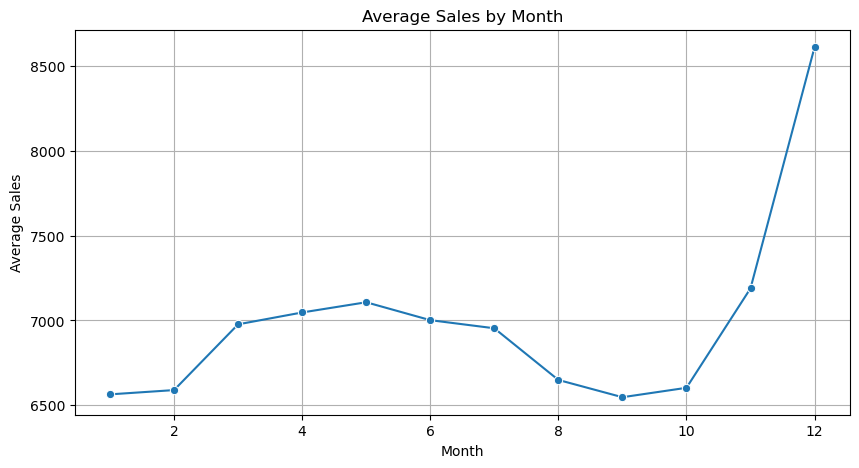

In [26]:
# Average sales by month
monthly_pattern = df_clean.groupby('Month')['Sales'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_pattern, x='Month', y='Sales', marker='o')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

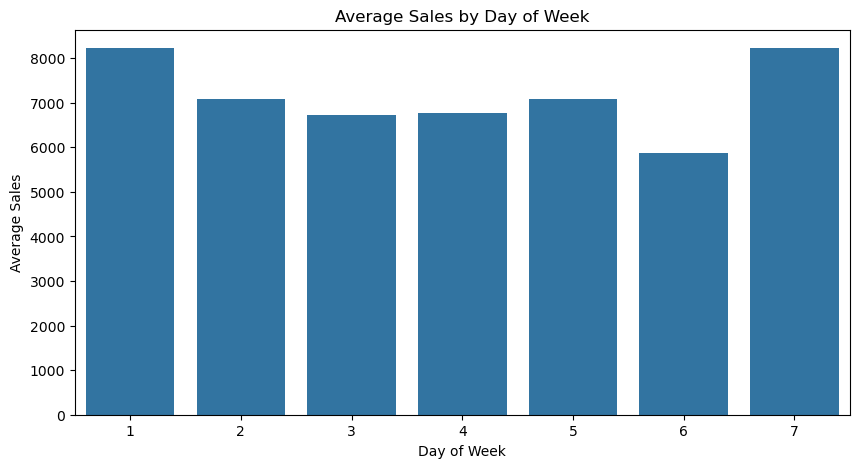

In [27]:
# Average sales by day of week
dow_pattern = df_clean.groupby('DayOfWeek')['Sales'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_pattern, x='DayOfWeek', y='Sales')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()

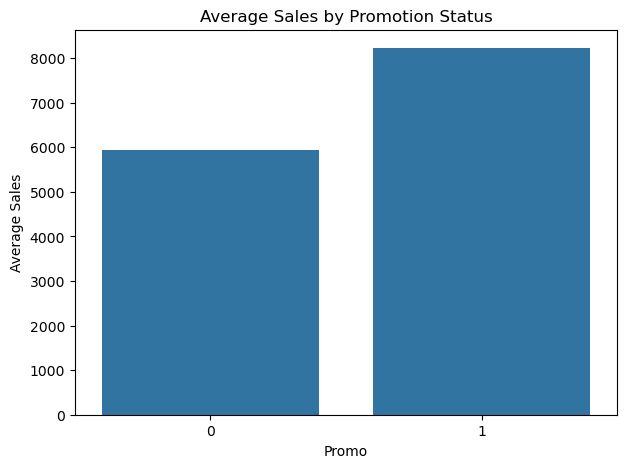

In [28]:
# Average sales by promo
promo_pattern = df_clean.groupby('Promo')['Sales'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=promo_pattern, x='Promo', y='Sales')
plt.title('Average Sales by Promotion Status')
plt.xlabel('Promo')
plt.ylabel('Average Sales')
plt.show()

In [29]:
# saving the daily datasets with time features
df_clean.to_csv("rossmann_clean_daily_with_time_features.csv", index=False)

print("Saved rossmann_clean_daily_with_time_features.csv")
print("Final daily feature dataset shape:", df_clean.shape)

Saved rossmann_clean_daily_with_time_features.csv
Final daily feature dataset shape: (844338, 29)


**4. Weekly and Monthly Forecasting Dataset Creation**

This section transforms the cleaned daily Rossmann dataset into weekly and monthly store-level forecasting datasets. Since the thesis focuses on weekly and monthly retail demand forecasting, daily sales records are aggregated by store and time period. Sales are summed, while promotion, holiday, and store-related variables are aggregated using suitable summary statistics.

In [30]:
# Create week start date for each daily record
df_clean['WeekStartDate'] = df_clean['Date'] - pd.to_timedelta(df_clean['Date'].dt.dayofweek, unit='D')

# Check result
display(df_clean[['Date', 'WeekStartDate', 'YearWeek']].head(10))

print("Minimum week:", df_clean['WeekStartDate'].min())
print("Maximum week:", df_clean['WeekStartDate'].max())
print("Number of weekly periods:", df_clean['WeekStartDate'].nunique())

,Date,WeekStartDate,YearWeek
1,2013-01-02,2012-12-31,2013-W01
2,2013-01-03,2012-12-31,2013-W01
3,2013-01-04,2012-12-31,2013-W01
4,2013-01-05,2012-12-31,2013-W01
6,2013-01-07,2013-01-07,2013-W02
7,2013-01-08,2013-01-07,2013-W02
8,2013-01-09,2013-01-07,2013-W02
9,2013-01-10,2013-01-07,2013-W02
10,2013-01-11,2013-01-07,2013-W02
11,2013-01-12,2013-01-07,2013-W02


Minimum week: 2012-12-31 00:00:00
Maximum week: 2015-07-27 00:00:00
Number of weekly periods: 135


In [31]:
# Create month start date for each daily record
df_clean['MonthStartDate'] = df_clean['Date'].values.astype('datetime64[M]')

# Check result
display(df_clean[['Date', 'MonthStartDate', 'YearMonth']].head(10))

print("Minimum month:", df_clean['MonthStartDate'].min())
print("Maximum month:", df_clean['MonthStartDate'].max())
print("Number of monthly periods:", df_clean['MonthStartDate'].nunique())

,Date,MonthStartDate,YearMonth
1,2013-01-02,2013-01-01,2013-01
2,2013-01-03,2013-01-01,2013-01
3,2013-01-04,2013-01-01,2013-01
4,2013-01-05,2013-01-01,2013-01
6,2013-01-07,2013-01-01,2013-01
7,2013-01-08,2013-01-01,2013-01
8,2013-01-09,2013-01-01,2013-01
9,2013-01-10,2013-01-01,2013-01
10,2013-01-11,2013-01-01,2013-01
11,2013-01-12,2013-01-01,2013-01


Minimum month: 2013-01-01 00:00:00
Maximum month: 2015-07-01 00:00:00
Number of monthly periods: 31


**Aggregating daily data into weekly store-level data**

In [32]:
weekly_df = (
    df_clean
    .groupby(['Store', 'WeekStartDate'], as_index=False)
    .agg({
        # Target
        'Sales': 'sum',

        # Operational / calendar features
        'Open': 'sum',
        'Promo': 'sum',
        'SchoolHoliday': 'sum',
        'IsWeekend': 'sum',
        'IsMonthStart': 'sum',
        'IsMonthEnd': 'sum',

        # Holiday feature
        'StateHoliday': lambda x: (x != 'none').sum(),

        # Time features
        'Year': 'first',
        'Month': 'first',
        'WeekOfYear': 'first',
        'Quarter': 'first',

        # Store-level features
        'StoreType': 'first',
        'Assortment': 'first',
        'CompetitionDistance': 'first',
        'CompetitionOpenKnown': 'first',
        'CompetitionOpenSinceMonth': 'first',
        'CompetitionOpenSinceYear': 'first',
        'Promo2': 'first',
        'Promo2SinceWeek': 'first',
        'Promo2SinceYear': 'first',
        'PromoInterval': 'first'
    })
)

# Rename aggregated columns for clarity
weekly_df = weekly_df.rename(columns={
    'Sales': 'WeeklySales',
    'Open': 'OpenDays',
    'Promo': 'PromoDays',
    'SchoolHoliday': 'SchoolHolidayDays',
    'IsWeekend': 'WeekendDays',
    'IsMonthStart': 'MonthStartDays',
    'IsMonthEnd': 'MonthEndDays',
    'StateHoliday': 'StateHolidayDays'
})

# Sort properly
weekly_df = weekly_df.sort_values(['Store', 'WeekStartDate']).reset_index(drop=True)

print("Weekly dataset shape:", weekly_df.shape)
display(weekly_df.head())

Weekly dataset shape: (145808, 24)


,Store,WeekStartDate,WeeklySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,WeekOfYear,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2012-12-31,19340,4,0,4,1,0,0,0,2013,1,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
1,1,2013-01-07,32952,6,5,5,1,0,0,0,2013,1,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
2,1,2013-01-14,25978,6,0,0,1,0,0,0,2013,1,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
3,1,2013-01-21,33071,6,5,0,1,0,0,0,2013,1,4,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
4,1,2013-01-28,28693,6,0,0,1,1,1,0,2013,1,5,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none


**Aggregating daily data into monthly store-level data**

In [33]:
monthly_df = (
    df_clean
    .groupby(['Store', 'MonthStartDate'], as_index=False)
    .agg({
        # Target
        'Sales': 'sum',

        # Operational / calendar features
        'Open': 'sum',
        'Promo': 'sum',
        'SchoolHoliday': 'sum',
        'IsWeekend': 'sum',
        'IsMonthStart': 'sum',
        'IsMonthEnd': 'sum',

        # Holiday feature
        'StateHoliday': lambda x: (x != 'none').sum(),

        # Time features
        'Year': 'first',
        'Month': 'first',
        'Quarter': 'first',

        # Store-level features
        'StoreType': 'first',
        'Assortment': 'first',
        'CompetitionDistance': 'first',
        'CompetitionOpenKnown': 'first',
        'CompetitionOpenSinceMonth': 'first',
        'CompetitionOpenSinceYear': 'first',
        'Promo2': 'first',
        'Promo2SinceWeek': 'first',
        'Promo2SinceYear': 'first',
        'PromoInterval': 'first'
    })
)

# Rename aggregated columns for clarity
monthly_df = monthly_df.rename(columns={
    'Sales': 'MonthlySales',
    'Open': 'OpenDays',
    'Promo': 'PromoDays',
    'SchoolHoliday': 'SchoolHolidayDays',
    'IsWeekend': 'WeekendDays',
    'IsMonthStart': 'MonthStartDays',
    'IsMonthEnd': 'MonthEndDays',
    'StateHoliday': 'StateHolidayDays'
})

# Sort properly
monthly_df = monthly_df.sort_values(['Store', 'MonthStartDate']).reset_index(drop=True)

print("Monthly dataset shape:", monthly_df.shape)
display(monthly_df.head())

Monthly dataset shape: (33465, 23)


,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2013-01-01,128431,26,10,9,4,0,1,0,2013,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
1,1,2013-02-01,125271,24,10,0,4,1,1,0,2013,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
2,1,2013-03-01,145169,25,14,4,5,1,0,0,2013,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
3,1,2013-04-01,118009,25,12,4,4,0,1,0,2013,4,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none
4,1,2013-05-01,118225,23,11,0,4,0,1,0,2013,5,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none


**Adding period index features, which help tree-based models to understand the order of time.**

In [34]:
# Weekly time index
weekly_df['TimeIndex'] = weekly_df.groupby('Store').cumcount() + 1

# Monthly time index
monthly_df['TimeIndex'] = monthly_df.groupby('Store').cumcount() + 1

display(weekly_df[['Store', 'WeekStartDate', 'TimeIndex', 'WeeklySales']].head(10))
display(monthly_df[['Store', 'MonthStartDate', 'TimeIndex', 'MonthlySales']].head(10))

,Store,WeekStartDate,TimeIndex,WeeklySales
0,1,2012-12-31,1,19340
1,1,2013-01-07,2,32952
2,1,2013-01-14,3,25978
3,1,2013-01-21,4,33071
4,1,2013-01-28,5,28693
5,1,2013-02-04,6,35771
6,1,2013-02-11,7,27880
7,1,2013-02-18,8,32951
8,1,2013-02-25,9,27027
9,1,2013-03-04,10,37016


,Store,MonthStartDate,TimeIndex,MonthlySales
0,1,2013-01-01,1,128431
1,1,2013-02-01,2,125271
2,1,2013-03-01,3,145169
3,1,2013-04-01,4,118009
4,1,2013-05-01,5,118225
5,1,2013-06-01,6,113411
6,1,2013-07-01,7,128032
7,1,2013-08-01,8,118320
8,1,2013-09-01,9,108867
9,1,2013-10-01,10,114641


In [35]:
#checking weekly and monthly datasets
print("Weekly dataset information:")
print("Shape:", weekly_df.shape)
print("Stores:", weekly_df['Store'].nunique())
print("Weeks:", weekly_df['WeekStartDate'].nunique())
print("Date range:", weekly_df['WeekStartDate'].min(), "to", weekly_df['WeekStartDate'].max())
print("Missing values:", weekly_df.isnull().sum().sum())

print("\nMonthly dataset information:")
print("Shape:", monthly_df.shape)
print("Stores:", monthly_df['Store'].nunique())
print("Months:", monthly_df['MonthStartDate'].nunique())
print("Date range:", monthly_df['MonthStartDate'].min(), "to", monthly_df['MonthStartDate'].max())
print("Missing values:", monthly_df.isnull().sum().sum())

Weekly dataset information:
Shape: (145808, 25)
Stores: 1115
Weeks: 135
Date range: 2012-12-31 00:00:00 to 2015-07-27 00:00:00
Missing values: 0

Monthly dataset information:
Shape: (33465, 24)
Stores: 1115
Months: 31
Date range: 2013-01-01 00:00:00 to 2015-07-01 00:00:00
Missing values: 0


In [36]:
#inspecting one selected store
selected_store = 1

store_weekly = weekly_df[weekly_df['Store'] == selected_store]
store_monthly = monthly_df[monthly_df['Store'] == selected_store]

print("Selected store:", selected_store)
print("Weekly records:", store_weekly.shape)
print("Monthly records:", store_monthly.shape)

display(store_weekly.head())
display(store_monthly.head())

Selected store: 1
Weekly records: (135, 25)
Monthly records: (31, 24)


,Store,WeekStartDate,WeeklySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,WeekOfYear,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2012-12-31,19340,4,0,4,1,0,0,0,2013,1,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-01-07,32952,6,5,5,1,0,0,0,2013,1,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-01-14,25978,6,0,0,1,0,0,0,2013,1,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3
3,1,2013-01-21,33071,6,5,0,1,0,0,0,2013,1,4,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4
4,1,2013-01-28,28693,6,0,0,1,1,1,0,2013,1,5,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5


,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2013-01-01,128431,26,10,9,4,0,1,0,2013,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-02-01,125271,24,10,0,4,1,1,0,2013,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-03-01,145169,25,14,4,5,1,0,0,2013,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3
3,1,2013-04-01,118009,25,12,4,4,0,1,0,2013,4,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4
4,1,2013-05-01,118225,23,11,0,4,0,1,0,2013,5,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5


In [37]:
#saving weekly and monthly datasets
weekly_df.to_csv("rossmann_weekly.csv", index=False)
monthly_df.to_csv("rossmann_monthly.csv", index=False)

print("Saved rossmann_weekly.csv")
print("Saved rossmann_monthly.csv")

Saved rossmann_weekly.csv
Saved rossmann_monthly.csv


**5. Exploratory Data Analysis**

This section explores weekly and monthly Rossmann sales patterns. The goal is to understand trends, seasonality, promotion effects, holiday effects, and store-level differences before building forecasting models. These visual analyses also support the explainable Decision Support System by identifying business factors that influence demand.

**Overall weekly sales trend**

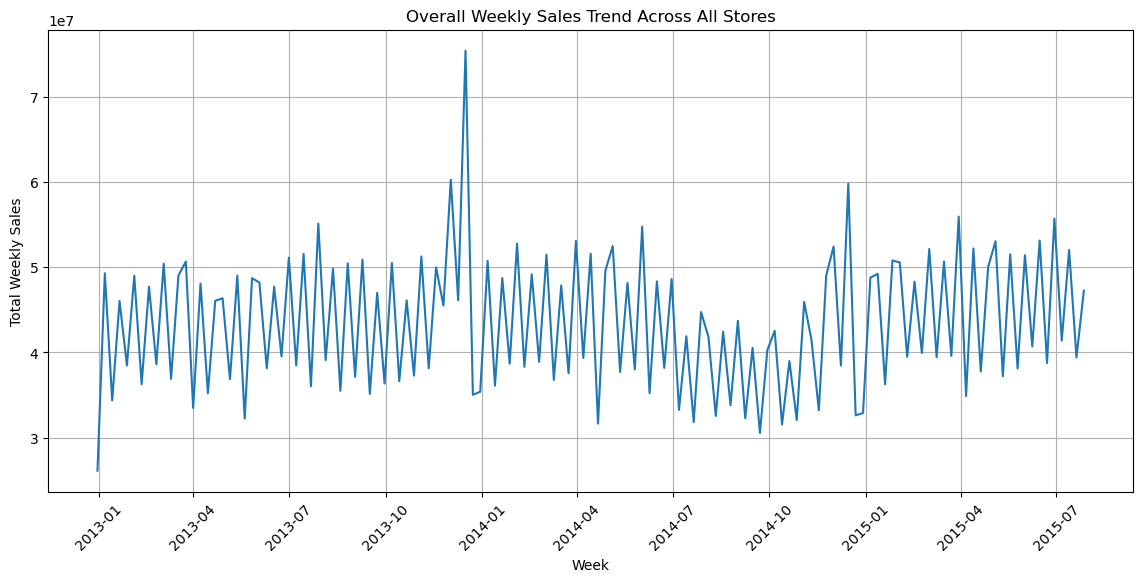

,WeekStartDate,WeeklySales
0,2012-12-31,26129335
1,2013-01-07,49275222
2,2013-01-14,34377765
3,2013-01-21,46040169
4,2013-01-28,38466029


In [38]:
# Overall weekly sales trend across all stores
weekly_trend = (
    weekly_df
    .groupby('WeekStartDate', as_index=False)['WeeklySales']
    .sum()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_trend, x='WeekStartDate', y='WeeklySales')
plt.title('Overall Weekly Sales Trend Across All Stores')
plt.xlabel('Week')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

display(weekly_trend.head())

**Overall monthly sales trend across all stores**

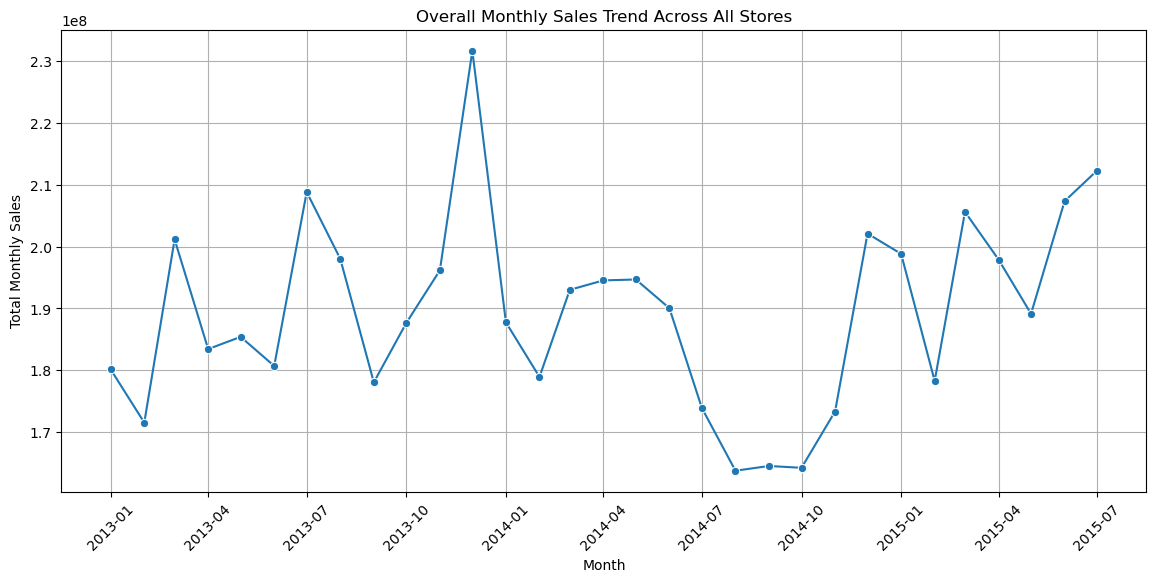

,MonthStartDate,MonthlySales
0,2013-01-01,180132207
1,2013-02-01,171534275
2,2013-03-01,201180369
3,2013-04-01,183431432
4,2013-05-01,185411063


In [39]:
# Overall monthly sales trend across all stores
monthly_trend = (
    monthly_df
    .groupby('MonthStartDate', as_index=False)['MonthlySales']
    .sum()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend, x='MonthStartDate', y='MonthlySales', marker='o')
plt.title('Overall Monthly Sales Trend Across All Stores')
plt.xlabel('Month')
plt.ylabel('Total Monthly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

display(monthly_trend.head())

**Sales by promotion activity**

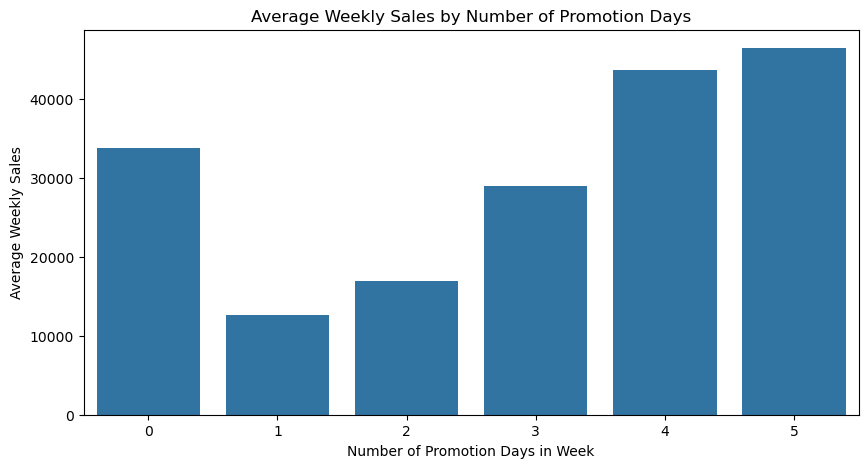

,PromoDays,WeeklySales
0,0,33780.030045
1,1,12588.899522
2,2,16927.875000
3,3,29009.904762
4,4,43641.197549
5,5,46465.629049


In [40]:
# Weekly sales by number of promo days
promo_weekly = (
    weekly_df
    .groupby('PromoDays', as_index=False)['WeeklySales']
    .mean()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=promo_weekly, x='PromoDays', y='WeeklySales')
plt.title('Average Weekly Sales by Number of Promotion Days')
plt.xlabel('Number of Promotion Days in Week')
plt.ylabel('Average Weekly Sales')
plt.show()

display(promo_weekly)

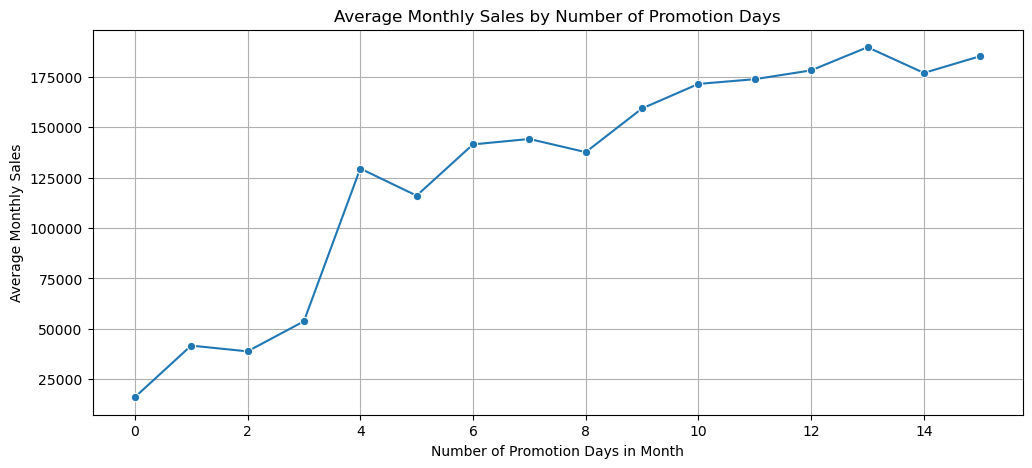

,PromoDays,MonthlySales
0,0,16130.750000
1,1,41713.666667
2,2,38862.200000
3,3,53745.000000
4,4,129475.000000


In [41]:
# Monthly sales by number of promo days
promo_monthly = (
    monthly_df
    .groupby('PromoDays', as_index=False)['MonthlySales']
    .mean()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=promo_monthly, x='PromoDays', y='MonthlySales', marker='o')
plt.title('Average Monthly Sales by Number of Promotion Days')
plt.xlabel('Number of Promotion Days in Month')
plt.ylabel('Average Monthly Sales')
plt.grid(True)
plt.show()

display(promo_monthly.head())

**sales by state holiday days**

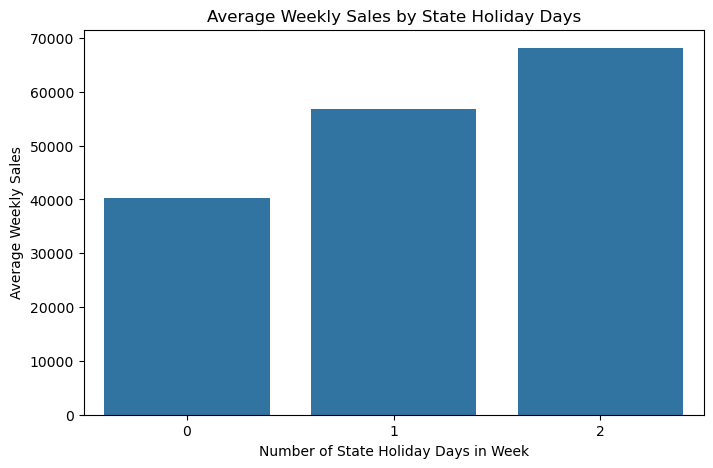

,StateHolidayDays,WeeklySales
0,0,40178.046139
1,1,56752.289286
2,2,68112.542857


In [42]:
# Weekly sales by state holiday days
holiday_weekly = (
    weekly_df
    .groupby('StateHolidayDays', as_index=False)['WeeklySales']
    .mean()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=holiday_weekly, x='StateHolidayDays', y='WeeklySales')
plt.title('Average Weekly Sales by State Holiday Days')
plt.xlabel('Number of State Holiday Days in Week')
plt.ylabel('Average Weekly Sales')
plt.show()

display(holiday_weekly)

**Sales by store type**

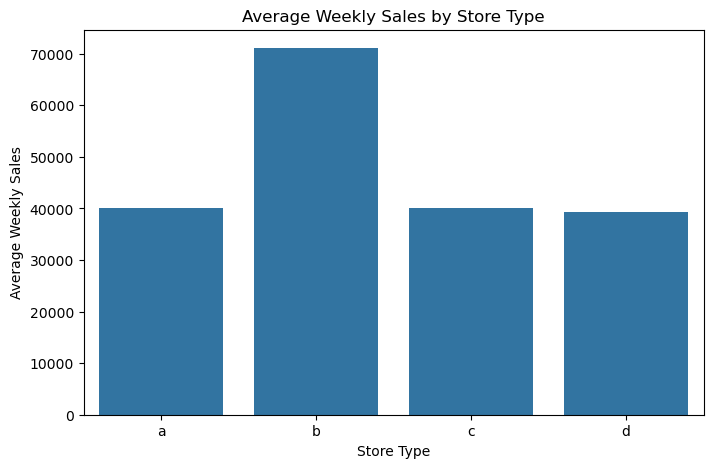

,StoreType,WeeklySales
0,a,40031.045870
1,b,71117.192943
2,c,40003.137341
3,d,39302.572310


In [43]:
# Average weekly sales by store type
storetype_weekly = (
    weekly_df
    .groupby('StoreType', as_index=False)['WeeklySales']
    .mean()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=storetype_weekly, x='StoreType', y='WeeklySales')
plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()

display(storetype_weekly)

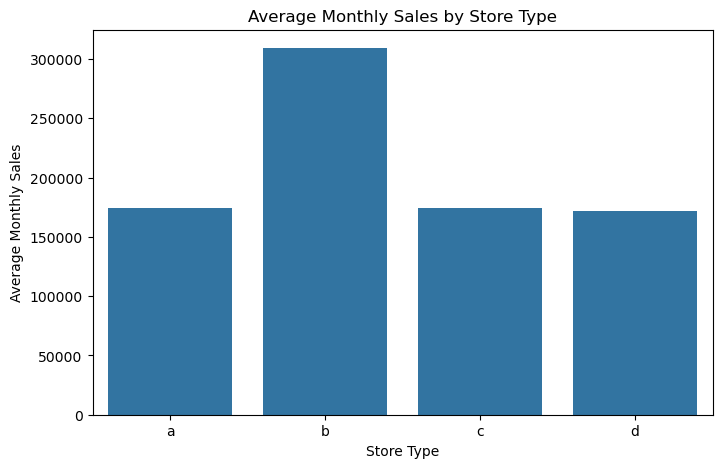

,StoreType,MonthlySales
0,a,174350.584357
1,b,309187.174757
2,c,174087.891976
3,d,171463.961053


In [44]:
# Average monthly sales by store type
storetype_monthly = (
    monthly_df
    .groupby('StoreType', as_index=False)['MonthlySales']
    .mean()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=storetype_monthly, x='StoreType', y='MonthlySales')
plt.title('Average Monthly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Monthly Sales')
plt.show()

display(storetype_monthly)

**sales by assortment type**

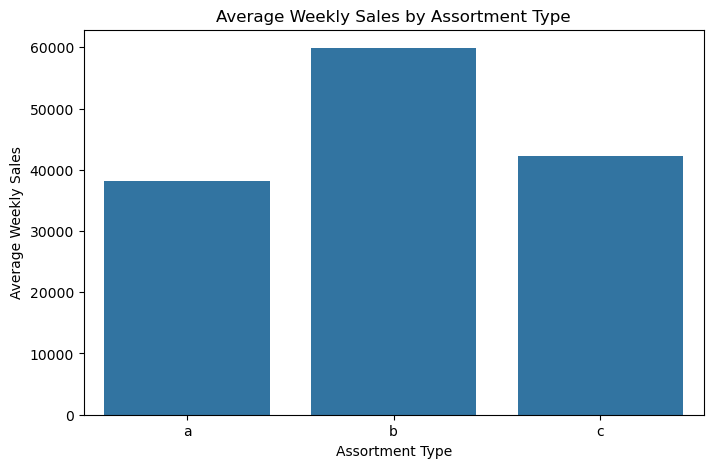

,Assortment,WeeklySales
0,a,38219.763734
1,b,59870.305485
2,c,42287.587396


In [45]:
# Average weekly sales by assortment
assortment_weekly = (
    weekly_df
    .groupby('Assortment', as_index=False)['WeeklySales']
    .mean()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=assortment_weekly, x='Assortment', y='WeeklySales')
plt.title('Average Weekly Sales by Assortment Type')
plt.xlabel('Assortment Type')
plt.ylabel('Average Weekly Sales')
plt.show()

display(assortment_weekly)

**store-1 weekly trend**

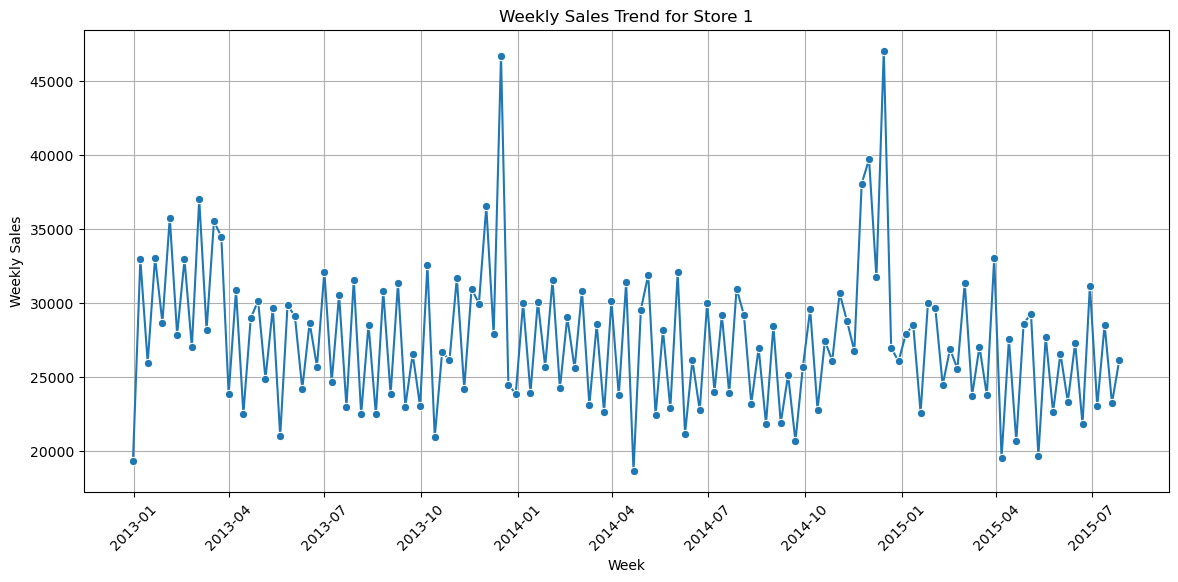

,Store,WeekStartDate,WeeklySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,WeekOfYear,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2012-12-31,19340,4,0,4,1,0,0,0,2013,1,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-01-07,32952,6,5,5,1,0,0,0,2013,1,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-01-14,25978,6,0,0,1,0,0,0,2013,1,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3
3,1,2013-01-21,33071,6,5,0,1,0,0,0,2013,1,4,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4
4,1,2013-01-28,28693,6,0,0,1,1,1,0,2013,1,5,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5


In [46]:
selected_store = 1

store_weekly = weekly_df[weekly_df['Store'] == selected_store]

plt.figure(figsize=(14, 6))
sns.lineplot(data=store_weekly, x='WeekStartDate', y='WeeklySales', marker='o')
plt.title(f'Weekly Sales Trend for Store {selected_store}')
plt.xlabel('Week')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

display(store_weekly.head())

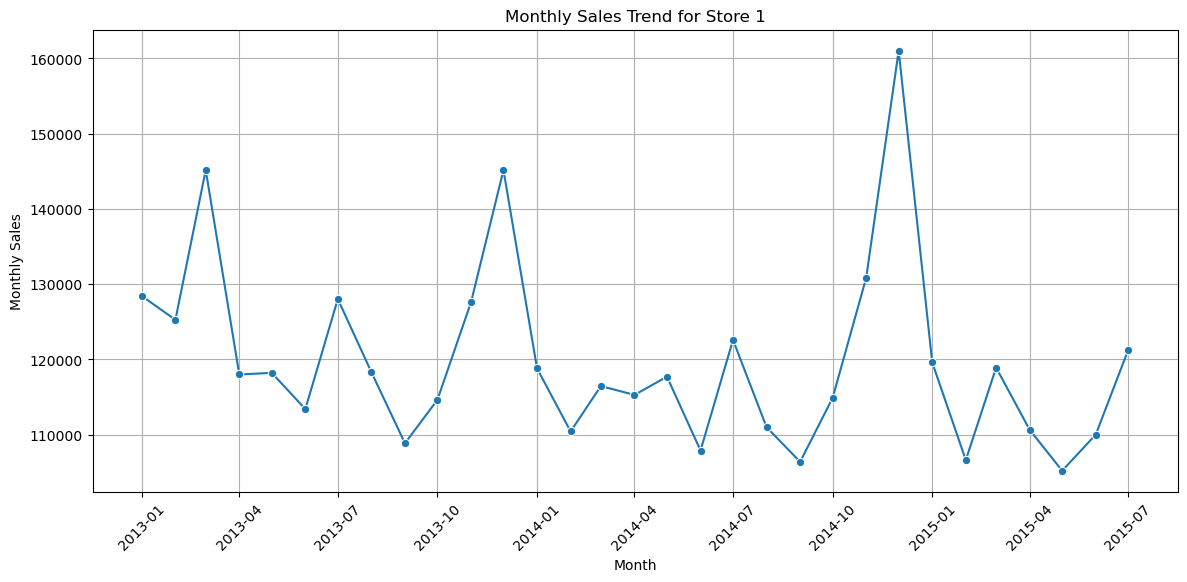

,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2013-01-01,128431,26,10,9,4,0,1,0,2013,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-02-01,125271,24,10,0,4,1,1,0,2013,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-03-01,145169,25,14,4,5,1,0,0,2013,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3
3,1,2013-04-01,118009,25,12,4,4,0,1,0,2013,4,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4
4,1,2013-05-01,118225,23,11,0,4,0,1,0,2013,5,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5


In [47]:
store_monthly = monthly_df[monthly_df['Store'] == selected_store]

plt.figure(figsize=(14, 6))
sns.lineplot(data=store_monthly, x='MonthStartDate', y='MonthlySales', marker='o')
plt.title(f'Monthly Sales Trend for Store {selected_store}')
plt.xlabel('Month')
plt.ylabel('Monthly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

display(store_monthly.head())

**Distribution of weekly and monthly sales**

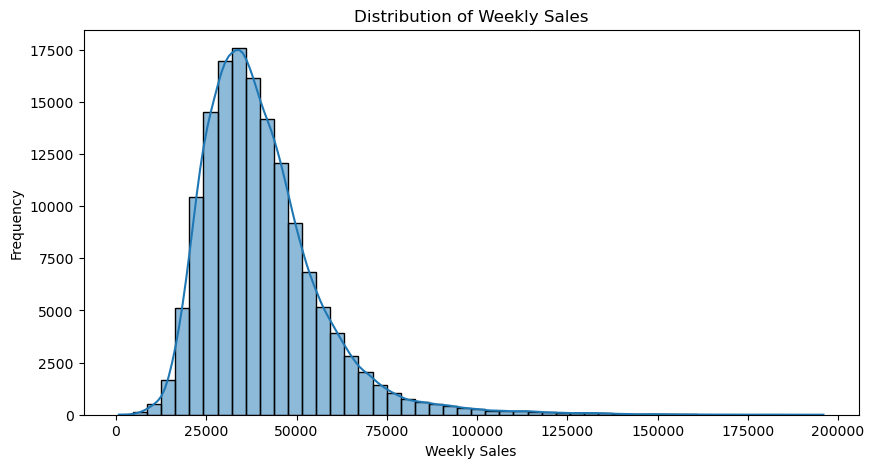

In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(weekly_df['WeeklySales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()

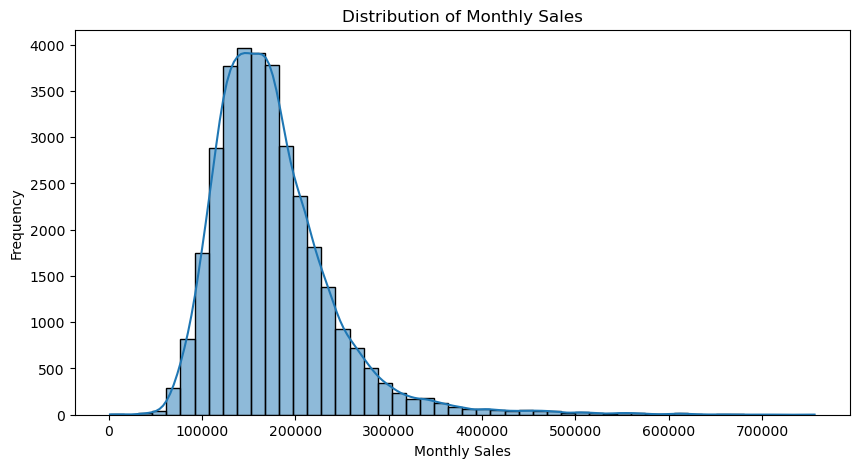

In [49]:
plt.figure(figsize=(10, 5))
sns.histplot(monthly_df['MonthlySales'], bins=50, kde=True)
plt.title('Distribution of Monthly Sales')
plt.xlabel('Monthly Sales')
plt.ylabel('Frequency')
plt.show()

In [50]:
# saving EDA summary tables
weekly_trend.to_csv("eda_weekly_trend.csv", index=False)
monthly_trend.to_csv("eda_monthly_trend.csv", index=False)
promo_weekly.to_csv("eda_promo_weekly.csv", index=False)
promo_monthly.to_csv("eda_promo_monthly.csv", index=False)
storetype_weekly.to_csv("eda_storetype_weekly.csv", index=False)
storetype_monthly.to_csv("eda_storetype_monthly.csv", index=False)

print("EDA summary tables saved.")

EDA summary tables saved.


**6. Time Series Analysis**

This section analyses temporal behaviour in the weekly and monthly Rossmann sales data. The goal is to examine trend, seasonality, moving averages, autocorrelation, partial autocorrelation, and decomposition patterns. These analyses help justify the use of lag features, rolling statistics, and forecasting algorithms in the machine learning workflow.

**Overall weekly trend with moving averages**

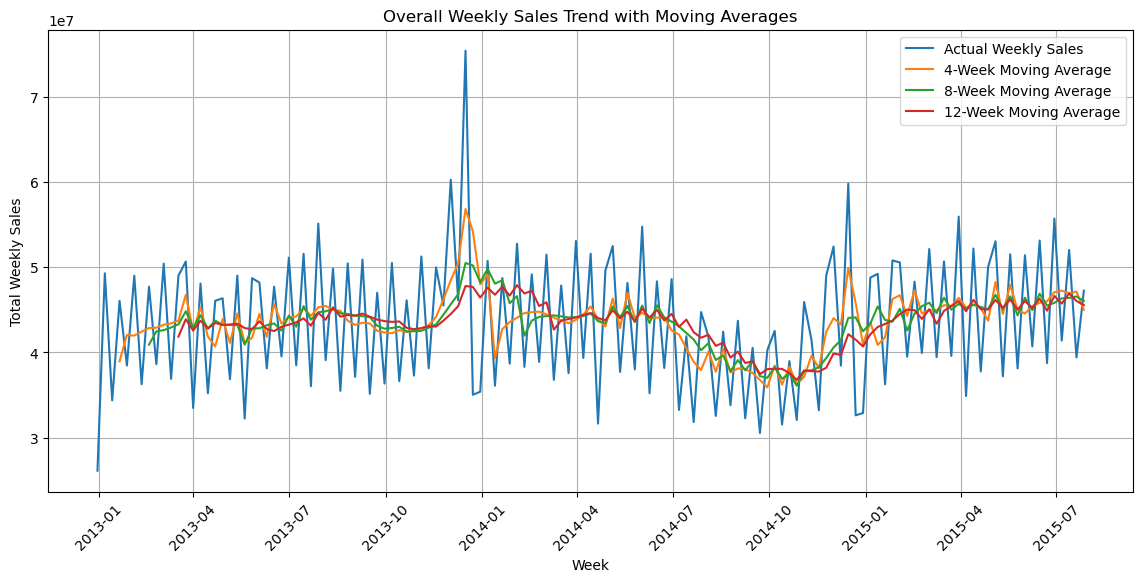

In [51]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Create moving averages on overall weekly trend
weekly_trend_ma = weekly_trend.copy()

weekly_trend_ma['MA_4'] = weekly_trend_ma['WeeklySales'].rolling(window=4).mean()
weekly_trend_ma['MA_8'] = weekly_trend_ma['WeeklySales'].rolling(window=8).mean()
weekly_trend_ma['MA_12'] = weekly_trend_ma['WeeklySales'].rolling(window=12).mean()

plt.figure(figsize=(14, 6))
plt.plot(weekly_trend_ma['WeekStartDate'], weekly_trend_ma['WeeklySales'], label='Actual Weekly Sales')
plt.plot(weekly_trend_ma['WeekStartDate'], weekly_trend_ma['MA_4'], label='4-Week Moving Average')
plt.plot(weekly_trend_ma['WeekStartDate'], weekly_trend_ma['MA_8'], label='8-Week Moving Average')
plt.plot(weekly_trend_ma['WeekStartDate'], weekly_trend_ma['MA_12'], label='12-Week Moving Average')
plt.title('Overall Weekly Sales Trend with Moving Averages')
plt.xlabel('Week')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

**Overall monthly trend with moving averages**

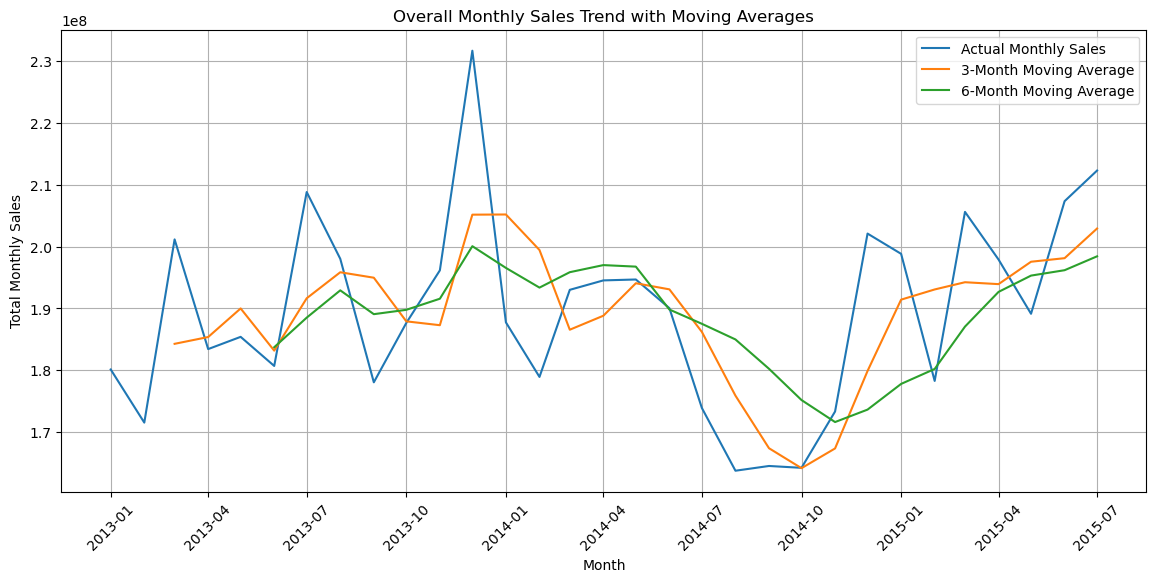

In [52]:
# Create moving averages on overall monthly trend
monthly_trend_ma = monthly_trend.copy()

monthly_trend_ma['MA_3'] = monthly_trend_ma['MonthlySales'].rolling(window=3).mean()
monthly_trend_ma['MA_6'] = monthly_trend_ma['MonthlySales'].rolling(window=6).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_trend_ma['MonthStartDate'], monthly_trend_ma['MonthlySales'], label='Actual Monthly Sales')
plt.plot(monthly_trend_ma['MonthStartDate'], monthly_trend_ma['MA_3'], label='3-Month Moving Average')
plt.plot(monthly_trend_ma['MonthStartDate'], monthly_trend_ma['MA_6'], label='6-Month Moving Average')
plt.title('Overall Monthly Sales Trend with Moving Averages')
plt.xlabel('Month')
plt.ylabel('Total Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

**Store-1 weekly moving average**

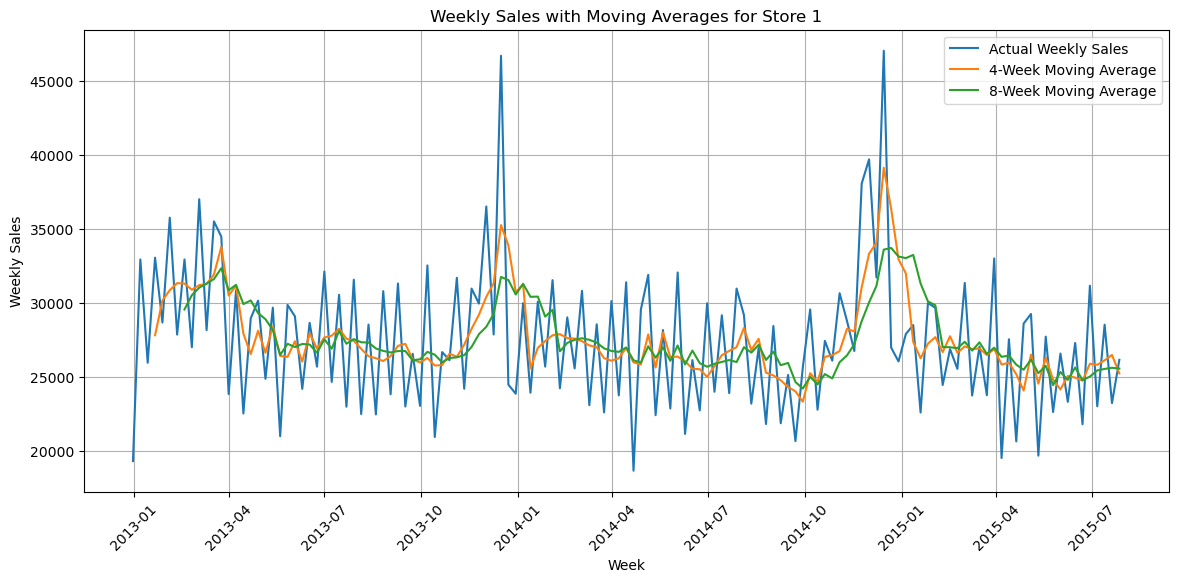

In [53]:
selected_store = 1

store_weekly_ts = weekly_df[weekly_df['Store'] == selected_store].copy()
store_weekly_ts = store_weekly_ts.sort_values('WeekStartDate')

store_weekly_ts['MA_4'] = store_weekly_ts['WeeklySales'].rolling(window=4).mean()
store_weekly_ts['MA_8'] = store_weekly_ts['WeeklySales'].rolling(window=8).mean()

plt.figure(figsize=(14, 6))
plt.plot(store_weekly_ts['WeekStartDate'], store_weekly_ts['WeeklySales'], label='Actual Weekly Sales')
plt.plot(store_weekly_ts['WeekStartDate'], store_weekly_ts['MA_4'], label='4-Week Moving Average')
plt.plot(store_weekly_ts['WeekStartDate'], store_weekly_ts['MA_8'], label='8-Week Moving Average')
plt.title(f'Weekly Sales with Moving Averages for Store {selected_store}')
plt.xlabel('Week')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

**Autocorrelation function (ACF) for store-1 weekly sales**

<Figure size 1200x500 with 0 Axes>

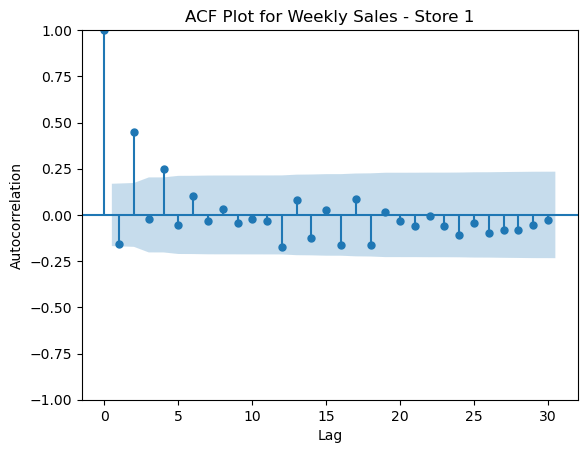

In [54]:
plt.figure(figsize=(12, 5))
plot_acf(store_weekly_ts['WeeklySales'], lags=30)
plt.title(f'ACF Plot for Weekly Sales - Store {selected_store}')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

**partial autocorrelation function (PACF) for store-1 weekly sales**

<Figure size 1200x500 with 0 Axes>

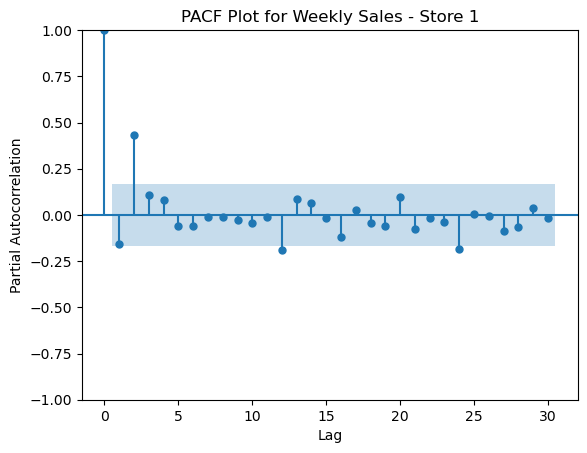

In [55]:
plt.figure(figsize=(12, 5))
plot_pacf(store_weekly_ts['WeeklySales'], lags=30, method='ywm')
plt.title(f'PACF Plot for Weekly Sales - Store {selected_store}')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

**Monthly ACF and PACF for store-1**

<Figure size 1200x500 with 0 Axes>

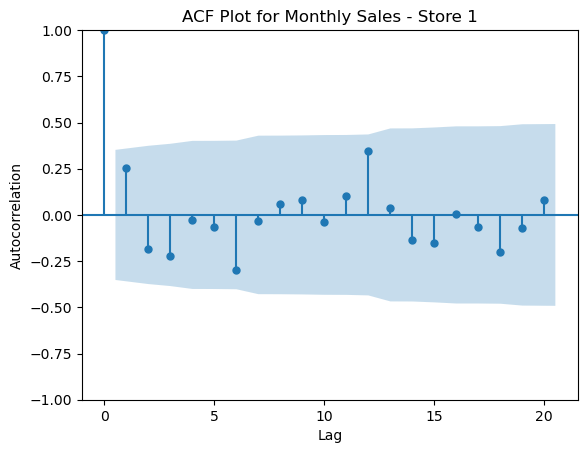

In [56]:
store_monthly_ts = monthly_df[monthly_df['Store'] == selected_store].copy()
store_monthly_ts = store_monthly_ts.sort_values('MonthStartDate')

plt.figure(figsize=(12, 5))
plot_acf(store_monthly_ts['MonthlySales'], lags=20)
plt.title(f'ACF Plot for Monthly Sales - Store {selected_store}')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

<Figure size 1200x500 with 0 Axes>

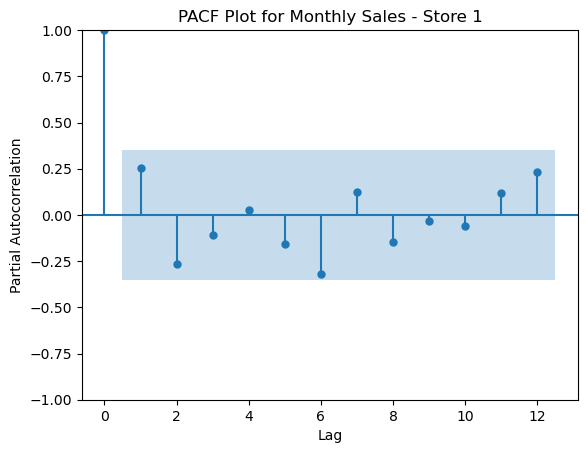

In [57]:
plt.figure(figsize=(12, 5))
plot_pacf(store_monthly_ts['MonthlySales'], lags=12, method='ywm')
plt.title(f'PACF Plot for Monthly Sales - Store {selected_store}')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

**Seasonal decomposition for store-1 weekly sales**

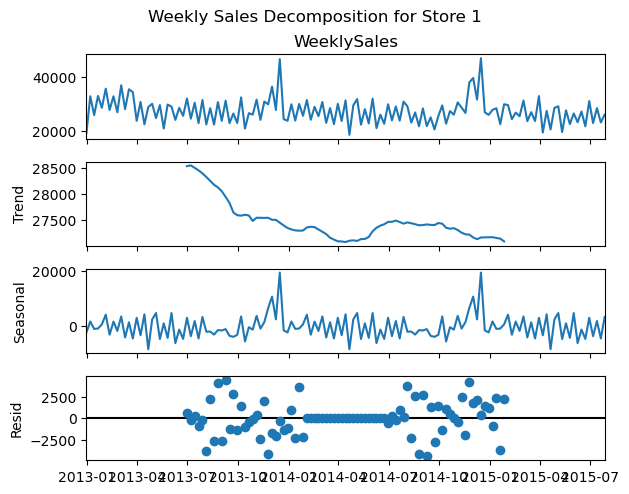

In [58]:
# Set date as index for decomposition
store_weekly_decomp = store_weekly_ts.set_index('WeekStartDate')

# Weekly decomposition with approximate yearly seasonality
decomp_weekly = seasonal_decompose(
    store_weekly_decomp['WeeklySales'],
    model='additive',
    period=52
)

decomp_weekly.plot()
plt.suptitle(f'Weekly Sales Decomposition for Store {selected_store}', y=1.02)
plt.show()

**Seasonal decomposition for store-1 monthly sales**

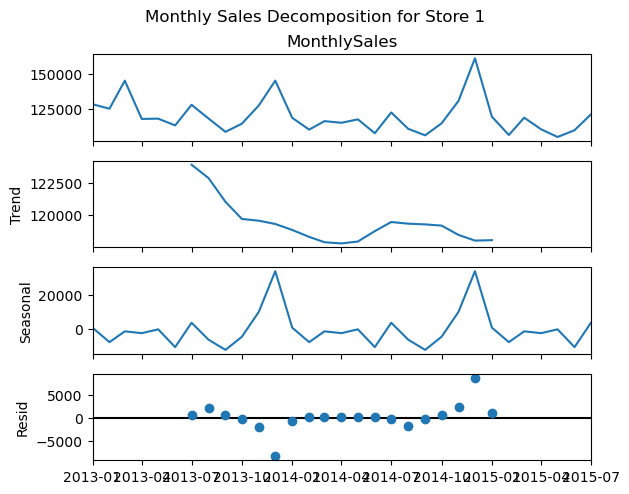

In [59]:
# Set date as index for decomposition
store_monthly_decomp = store_monthly_ts.set_index('MonthStartDate')

decomp_monthly = seasonal_decompose(
    store_monthly_decomp['MonthlySales'],
    model='additive',
    period=12
)

decomp_monthly.plot()
plt.suptitle(f'Monthly Sales Decomposition for Store {selected_store}', y=1.02)
plt.show()

In [60]:
# saving selected store time series analysis data
store_weekly_ts.to_csv("store_1_weekly_timeseries_analysis.csv", index=False)
store_monthly_ts.to_csv("store_1_monthly_timeseries_analysis.csv", index=False)

print("Saved selected store time series analysis files.")

Saved selected store time series analysis files.


**7. Lag, Rolling, and Exponential Moving Average Feature Engineering**

This section creates historical sales-based features for weekly and monthly forecasting. Lag features represent previous sales values, rolling features capture recent average demand patterns, and exponential moving averages give more weight to recent observations. These features are created separately for each store to avoid mixing sales patterns between stores.

In [61]:
# Create a copy of weekly dataset
weekly_model_df = weekly_df.copy()

# Sort by Store and WeekStartDate
weekly_model_df = weekly_model_df.sort_values(['Store', 'WeekStartDate']).reset_index(drop=True)

# Weekly lag features
weekly_lags = [1, 2, 4, 8, 52]

for lag in weekly_lags:
    weekly_model_df[f'sales_lag_{lag}'] = (
        weekly_model_df
        .groupby('Store')['WeeklySales']
        .shift(lag)
    )

# Weekly rolling mean and rolling standard deviation features
weekly_windows = [4, 8, 12]

for window in weekly_windows:
    weekly_model_df[f'rolling_mean_{window}'] = (
        weekly_model_df
        .groupby('Store')['WeeklySales']
        .shift(1)
        .rolling(window=window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    weekly_model_df[f'rolling_std_{window}'] = (
        weekly_model_df
        .groupby('Store')['WeeklySales']
        .shift(1)
        .rolling(window=window)
        .std()
        .reset_index(level=0, drop=True)
    )

# Weekly EMA features
weekly_ema_windows = [4, 8]

for span in weekly_ema_windows:
    weekly_model_df[f'EMA_{span}'] = (
        weekly_model_df
        .groupby('Store')['WeeklySales']
        .shift(1)
        .ewm(span=span, adjust=False)
        .mean()
        .reset_index(level=0, drop=True)
    )

print("Weekly model dataset shape before removing NaN:", weekly_model_df.shape)
display(weekly_model_df.head(15))

Weekly model dataset shape before removing NaN: (145808, 38)


,Store,WeekStartDate,WeeklySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,WeekOfYear,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex,sales_lag_1,sales_lag_2,sales_lag_4,sales_lag_8,sales_lag_52,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_12,rolling_std_12,EMA_4,EMA_8
0,1,2012-12-31,19340,4,0,4,1,0,0,0,2013,1,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-07,32952,6,5,5,1,0,0,0,2013,1,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2,19340.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19340.000000,19340.000000
2,1,2013-01-14,25978,6,0,0,1,0,0,0,2013,1,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3,32952.0,19340.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24784.800000,22364.888889
3,1,2013-01-21,33071,6,5,0,1,0,0,0,2013,1,4,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4,25978.0,32952.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25262.080000,23167.802469
4,1,2013-01-28,28693,6,0,0,1,1,1,0,2013,1,5,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5,33071.0,25978.0,19340.0,NaN,NaN,27835.25,6562.846404,NaN,NaN,NaN,NaN,28385.648000,25368.513032
5,1,2013-02-04,35771,6,5,0,1,0,0,0,2013,2,6,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,6,28693.0,33071.0,32952.0,NaN,NaN,30173.50,3459.752833,NaN,NaN,NaN,NaN,28508.588800,26107.287913
6,1,2013-02-11,27880,6,0,0,1,0,0,0,2013,2,7,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,7,35771.0,28693.0,25978.0,NaN,NaN,30878.25,4379.304463,NaN,NaN,NaN,NaN,31413.553280,28254.779488
7,1,2013-02-18,32951,6,5,0,1,0,0,0,2013,2,8,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,8,27880.0,35771.0,33071.0,NaN,NaN,31353.75,3724.136354,NaN,NaN,NaN,NaN,30000.131968,28171.495158
8,1,2013-02-25,27027,6,0,0,1,1,1,0,2013,2,9,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,9,32951.0,27880.0,28693.0,19340.0,NaN,31323.75,3706.131620,29579.500,5274.715402,NaN,NaN,31180.479181,29233.607345
9,1,2013-03-04,37016,6,5,0,1,0,0,0,2013,3,10,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,10,27027.0,32951.0,35771.0,32952.0,NaN,30907.25,4165.475593,30540.375,3566.511058,NaN,NaN,29519.087508,28743.250157


**Creating monthly lag and rolling features**

In [62]:
# Create a copy of monthly dataset
monthly_model_df = monthly_df.copy()

# Sort by Store and MonthStartDate
monthly_model_df = monthly_model_df.sort_values(['Store', 'MonthStartDate']).reset_index(drop=True)

# Monthly lag features
monthly_lags = [1, 2, 3, 12]

for lag in monthly_lags:
    monthly_model_df[f'sales_lag_{lag}'] = (
        monthly_model_df
        .groupby('Store')['MonthlySales']
        .shift(lag)
    )

# Monthly rolling mean and rolling standard deviation features
monthly_windows = [3, 6]

for window in monthly_windows:
    monthly_model_df[f'rolling_mean_{window}'] = (
        monthly_model_df
        .groupby('Store')['MonthlySales']
        .shift(1)
        .rolling(window=window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    monthly_model_df[f'rolling_std_{window}'] = (
        monthly_model_df
        .groupby('Store')['MonthlySales']
        .shift(1)
        .rolling(window=window)
        .std()
        .reset_index(level=0, drop=True)
    )

# Monthly EMA features
monthly_ema_windows = [3, 6]

for span in monthly_ema_windows:
    monthly_model_df[f'EMA_{span}'] = (
        monthly_model_df
        .groupby('Store')['MonthlySales']
        .shift(1)
        .ewm(span=span, adjust=False)
        .mean()
        .reset_index(level=0, drop=True)
    )

print("Monthly model dataset shape before removing NaN:", monthly_model_df.shape)
display(monthly_model_df.head(15))

Monthly model dataset shape before removing NaN: (33465, 34)


,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,EMA_3,EMA_6
0,1,2013-01-01,128431,26,10,9,4,0,1,0,2013,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-02-01,125271,24,10,0,4,1,1,0,2013,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2,128431.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128431.000000,128431.000000
2,1,2013-03-01,145169,25,14,4,5,1,0,0,2013,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3,125271.0,128431.0,NaN,NaN,NaN,NaN,NaN,NaN,126851.000000,127528.142857
3,1,2013-04-01,118009,25,12,4,4,0,1,0,2013,4,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,4,145169.0,125271.0,128431.0,NaN,132957.000000,10693.273961,NaN,NaN,136010.000000,132568.387755
4,1,2013-05-01,118225,23,11,0,4,0,1,0,2013,5,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,5,118009.0,145169.0,125271.0,NaN,129483.000000,14061.369350,NaN,NaN,127009.500000,128408.562682
5,1,2013-06-01,113411,25,10,0,5,1,0,0,2013,6,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,6,118225.0,118009.0,145169.0,NaN,127134.333333,15618.852881,NaN,NaN,122617.250000,125498.973344
6,1,2013-07-01,128032,27,13,22,4,1,1,0,2013,7,3,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,7,113411.0,118225.0,118009.0,NaN,116548.333333,2719.155997,124752.666667,11378.456375,118014.125000,122045.266675
7,1,2013-08-01,118320,27,12,14,5,1,1,0,2013,8,3,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,8,128032.0,113411.0,118225.0,NaN,119889.333333,7451.235759,124686.166667,11353.798526,123023.062500,123755.761910
8,1,2013-09-01,108867,25,10,0,4,0,1,0,2013,9,3,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,9,118320.0,128032.0,113411.0,NaN,119921.000000,7440.820586,123527.666667,11633.374569,120671.531250,122202.687079
9,1,2013-10-01,114641,26,10,11,4,1,1,0,2013,10,4,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,10,108867.0,118320.0,128032.0,NaN,118406.333333,9582.791677,117477.333333,6381.624516,114769.265625,118392.490771


**Check missing values created by lag features**

In [63]:
print("Weekly missing values after feature engineering:")
weekly_missing = weekly_model_df.isnull().sum()
print(weekly_missing[weekly_missing > 0])

print("\nMonthly missing values after feature engineering:")
monthly_missing = monthly_model_df.isnull().sum()
print(monthly_missing[monthly_missing > 0])

Weekly missing values after feature engineering:
sales_lag_1         1115
sales_lag_2         2230
sales_lag_4         4460
sales_lag_8         8920
sales_lag_52       57980
rolling_mean_4      4460
rolling_std_4       4460
rolling_mean_8      8920
rolling_std_8       8920
rolling_mean_12    13380
rolling_std_12     13380
EMA_4                  1
EMA_8                  1
dtype: int64

Monthly missing values after feature engineering:
sales_lag_1        1115
sales_lag_2        2230
sales_lag_3        3345
sales_lag_12      13380
rolling_mean_3     3345
rolling_std_3      3345
rolling_mean_6     6690
rolling_std_6      6690
EMA_3                 1
EMA_6                 1
dtype: int64


**Remove rows with missing lag/rolling values**

In [64]:
# Remove rows with missing values caused by lag/rolling/EMA features
weekly_model_df = weekly_model_df.dropna().reset_index(drop=True)
monthly_model_df = monthly_model_df.dropna().reset_index(drop=True)

print("Weekly model dataset shape after removing NaN:", weekly_model_df.shape)
print("Monthly model dataset shape after removing NaN:", monthly_model_df.shape)

print("\nWeekly missing values remaining:", weekly_model_df.isnull().sum().sum())
print("Monthly missing values remaining:", monthly_model_df.isnull().sum().sum())

Weekly model dataset shape after removing NaN: (87828, 38)
Monthly model dataset shape after removing NaN: (20085, 34)

Weekly missing values remaining: 0
Monthly missing values remaining: 0


**Inspect final weekly and monthly modelling datasets**

In [65]:
print("Weekly modelling columns:")
print(weekly_model_df.columns.tolist())

print("\nMonthly modelling columns:")
print(monthly_model_df.columns.tolist())

print("\nWeekly model preview:")
display(weekly_model_df.head())

print("\nMonthly model preview:")
display(monthly_model_df.head())

Weekly modelling columns:
['Store', 'WeekStartDate', 'WeeklySales', 'OpenDays', 'PromoDays', 'SchoolHolidayDays', 'WeekendDays', 'MonthStartDays', 'MonthEndDays', 'StateHolidayDays', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'TimeIndex', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8', 'sales_lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'EMA_4', 'EMA_8']

Monthly modelling columns:
['Store', 'MonthStartDate', 'MonthlySales', 'OpenDays', 'PromoDays', 'SchoolHolidayDays', 'WeekendDays', 'MonthStartDays', 'MonthEndDays', 'StateHolidayDays', 'Year', 'Month', 'Quarter', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2Si

,Store,WeekStartDate,WeeklySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,WeekOfYear,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex,sales_lag_1,sales_lag_2,sales_lag_4,sales_lag_8,sales_lag_52,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_12,rolling_std_12,EMA_4,EMA_8
0,1,2013-12-30,23887,5,0,5,1,0,1,0,2013,12,1,4,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,53,24501.0,46699.0,36526.0,31713.0,19340.0,33903.25,9919.805185,31563.125,7308.305519,29906.000000,6789.807522,31940.065210,31378.360166
1,1,2014-01-06,30000,6,5,5,1,0,0,0,2014,1,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,54,23887.0,24501.0,27887.0,24223.0,32952.0,30743.50,10781.434212,30584.875,7793.073434,29184.166667,6942.011365,28718.839126,29713.613463
2,1,2014-01-13,23954,6,0,0,1,0,0,0,2014,1,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,55,30000.0,23887.0,46699.0,30984.0,25978.0,31271.75,10645.734337,31307.000,7375.837618,29936.916667,6441.702943,29231.303475,29777.254915
3,1,2014-01-20,30102,6,5,0,1,0,0,0,2014,1,4,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,56,23954.0,30000.0,24501.0,29972.0,33071.0,25585.50,2955.821657,30428.250,7824.919274,29708.166667,6613.582262,27120.382085,28483.198267
4,1,2014-01-27,25718,6,0,0,1,1,1,0,2014,1,5,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,57,30102.0,23954.0,23887.0,36526.0,28693.0,26985.75,3539.796451,30444.500,7823.971352,30037.333333,6518.105892,28313.029251,28842.931986



Monthly model preview:


,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,Year,Month,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,EMA_3,EMA_6
0,1,2014-01-01,118814,26,10,8,4,0,1,0,2014,1,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,13,145168.0,127596.0,114641.0,128431.0,129135.000000,15321.580304,123770.666667,12851.598121,133159.283203,127374.038911
1,1,2014-02-01,110434,24,10,0,4,1,1,0,2014,2,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,14,118814.0,145168.0,127596.0,125271.0,130526.000000,13419.091027,122234.333333,12791.133909,125986.641602,124928.313508
2,1,2014-03-01,116467,26,11,0,5,1,1,0,2014,3,1,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,15,110434.0,118814.0,145168.0,145169.0,124805.333333,18125.527450,120920.000000,13650.103018,118210.320801,120787.081077
3,1,2014-04-01,115292,24,11,9,4,1,1,0,2014,4,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,16,116467.0,110434.0,118814.0,118009.0,115238.333333,4322.998535,122186.666667,12621.840558,117338.660400,119552.772198
4,1,2014-05-01,117715,25,11,0,5,0,1,0,2014,5,2,c,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,17,115292.0,116467.0,110434.0,118225.0,114064.333333,3198.381830,122295.166667,12546.577261,116315.330200,118335.408713


In [66]:
#saving modelling datasets
weekly_model_df.to_csv("rossmann_weekly_model_features.csv", index=False)
monthly_model_df.to_csv("rossmann_monthly_model_features.csv", index=False)

print("Saved rossmann_weekly_model_features.csv")
print("Saved rossmann_monthly_model_features.csv")

Saved rossmann_weekly_model_features.csv
Saved rossmann_monthly_model_features.csv


**8. Modelling Dataset Preparation and Chronological Split**

This section prepares the weekly and monthly modelling datasets for machine learning. Categorical variables are encoded, target variables are separated from input features, and the data is split chronologically into training, validation, and test sets. A chronological split is used instead of a random split to avoid data leakage in time series forecasting.

**Define evaluation metrices**

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error.
    Small epsilon is used to avoid division by zero.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), epsilon))) * 100

def rmspe(y_true, y_pred):
    """
    Root Mean Squared Percentage Error.
    Commonly used in retail demand forecasting.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.sqrt(np.mean(((y_true - y_pred) / np.maximum(np.abs(y_true), epsilon)) ** 2)) * 100

def evaluate_model(y_true, y_pred):
    """
    Returns MAE, RMSE, MAPE, and RMSPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = mape(y_true, y_pred)
    rmspe_value = rmspe(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape_value,
        "RMSPE": rmspe_value
    }

**Encode categorical variables using one-hot encoding**

In [68]:
# Make copies before encoding
weekly_encoded = weekly_model_df.copy()
monthly_encoded = monthly_model_df.copy()

categorical_cols = ['StoreType', 'Assortment', 'PromoInterval']

weekly_encoded = pd.get_dummies(
    weekly_encoded,
    columns=categorical_cols,
    drop_first=False
)

monthly_encoded = pd.get_dummies(
    monthly_encoded,
    columns=categorical_cols,
    drop_first=False
)

print("Weekly encoded shape:", weekly_encoded.shape)
print("Monthly encoded shape:", monthly_encoded.shape)

print("\nWeekly encoded columns:")
print(weekly_encoded.columns.tolist())

Weekly encoded shape: (87828, 46)
Monthly encoded shape: (20085, 42)

Weekly encoded columns:
['Store', 'WeekStartDate', 'WeeklySales', 'OpenDays', 'PromoDays', 'SchoolHolidayDays', 'WeekendDays', 'MonthStartDays', 'MonthEndDays', 'StateHolidayDays', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'CompetitionDistance', 'CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'TimeIndex', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8', 'sales_lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'EMA_4', 'EMA_8', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_none']


**Defining features and target columns**

In [69]:
weekly_target = 'WeeklySales'

weekly_drop_cols = [
    'WeeklySales',
    'WeekStartDate'
]

# Customers is not in weekly_model_df, but keep this guard for safety
if 'Customers' in weekly_encoded.columns:
    weekly_drop_cols.append('Customers')

weekly_features = [col for col in weekly_encoded.columns if col not in weekly_drop_cols]

print("Weekly target:", weekly_target)
print("Number of weekly features:", len(weekly_features))
print(weekly_features)

Weekly target: WeeklySales
Number of weekly features: 44
['Store', 'OpenDays', 'PromoDays', 'SchoolHolidayDays', 'WeekendDays', 'MonthStartDays', 'MonthEndDays', 'StateHolidayDays', 'Year', 'Month', 'WeekOfYear', 'Quarter', 'CompetitionDistance', 'CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'TimeIndex', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8', 'sales_lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'EMA_4', 'EMA_8', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_none']


In [70]:
monthly_target = 'MonthlySales'

monthly_drop_cols = [
    'MonthlySales',
    'MonthStartDate'
]

if 'Customers' in monthly_encoded.columns:
    monthly_drop_cols.append('Customers')

monthly_features = [col for col in monthly_encoded.columns if col not in monthly_drop_cols]

print("Monthly target:", monthly_target)
print("Number of monthly features:", len(monthly_features))
print(monthly_features)

Monthly target: MonthlySales
Number of monthly features: 40
['Store', 'OpenDays', 'PromoDays', 'SchoolHolidayDays', 'WeekendDays', 'MonthStartDays', 'MonthEndDays', 'StateHolidayDays', 'Year', 'Month', 'Quarter', 'CompetitionDistance', 'CompetitionOpenKnown', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'TimeIndex', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'EMA_3', 'EMA_6', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_none']


**Creating chronological split function**

In [71]:
def chronological_split(df, date_col, train_end, val_end):
    """
    Splits dataframe chronologically into train, validation, and test sets.
    
    train: dates <= train_end
    validation: train_end < dates <= val_end
    test: dates > val_end
    """
    train_df = df[df[date_col] <= train_end].copy()
    val_df = df[(df[date_col] > train_end) & (df[date_col] <= val_end)].copy()
    test_df = df[df[date_col] > val_end].copy()
    
    return train_df, val_df, test_df

**Weekly chronological split**

In [72]:
# Weekly chronological split
weekly_train_df, weekly_val_df, weekly_test_df = chronological_split(
    weekly_encoded,
    date_col='WeekStartDate',
    train_end='2014-12-31',
    val_end='2015-04-30'
)

print("Weekly train shape:", weekly_train_df.shape)
print("Weekly validation shape:", weekly_val_df.shape)
print("Weekly test shape:", weekly_test_df.shape)

print("\nWeekly train date range:", weekly_train_df['WeekStartDate'].min(), "to", weekly_train_df['WeekStartDate'].max())
print("Weekly validation date range:", weekly_val_df['WeekStartDate'].min(), "to", weekly_val_df['WeekStartDate'].max())
print("Weekly test date range:", weekly_test_df['WeekStartDate'].min(), "to", weekly_test_df['WeekStartDate'].max())

Weekly train shape: (54396, 46)
Weekly validation shape: (18945, 46)
Weekly test shape: (14487, 46)

Weekly train date range: 2013-12-30 00:00:00 to 2014-12-29 00:00:00
Weekly validation date range: 2015-01-05 00:00:00 to 2015-04-27 00:00:00
Weekly test date range: 2015-05-04 00:00:00 to 2015-07-27 00:00:00


**Monthly chronological split**

In [73]:
# Monthly chronological split
monthly_train_df, monthly_val_df, monthly_test_df = chronological_split(
    monthly_encoded,
    date_col='MonthStartDate',
    train_end='2014-12-31',
    val_end='2015-04-30'
)

print("Monthly train shape:", monthly_train_df.shape)
print("Monthly validation shape:", monthly_val_df.shape)
print("Monthly test shape:", monthly_test_df.shape)

print("\nMonthly train date range:", monthly_train_df['MonthStartDate'].min(), "to", monthly_train_df['MonthStartDate'].max())
print("Monthly validation date range:", monthly_val_df['MonthStartDate'].min(), "to", monthly_val_df['MonthStartDate'].max())
print("Monthly test date range:", monthly_test_df['MonthStartDate'].min(), "to", monthly_test_df['MonthStartDate'].max())

Monthly train shape: (12280, 42)
Monthly validation shape: (4460, 42)
Monthly test shape: (3345, 42)

Monthly train date range: 2014-01-01 00:00:00 to 2014-12-01 00:00:00
Monthly validation date range: 2015-01-01 00:00:00 to 2015-04-01 00:00:00
Monthly test date range: 2015-05-01 00:00:00 to 2015-07-01 00:00:00


In [74]:
# Weekly X and y
X_weekly_train = weekly_train_df[weekly_features]
y_weekly_train = weekly_train_df[weekly_target]

X_weekly_val = weekly_val_df[weekly_features]
y_weekly_val = weekly_val_df[weekly_target]

X_weekly_test = weekly_test_df[weekly_features]
y_weekly_test = weekly_test_df[weekly_target]

# Monthly X and y
X_monthly_train = monthly_train_df[monthly_features]
y_monthly_train = monthly_train_df[monthly_target]

X_monthly_val = monthly_val_df[monthly_features]
y_monthly_val = monthly_val_df[monthly_target]

X_monthly_test = monthly_test_df[monthly_features]
y_monthly_test = monthly_test_df[monthly_target]

print("Weekly X train:", X_weekly_train.shape)
print("Weekly y train:", y_weekly_train.shape)
print("Weekly X validation:", X_weekly_val.shape)
print("Weekly y validation:", y_weekly_val.shape)
print("Weekly X test:", X_weekly_test.shape)
print("Weekly y test:", y_weekly_test.shape)

print("\nMonthly X train:", X_monthly_train.shape)
print("Monthly y train:", y_monthly_train.shape)
print("Monthly X validation:", X_monthly_val.shape)
print("Monthly y validation:", y_monthly_val.shape)
print("Monthly X test:", X_monthly_test.shape)
print("Monthly y test:", y_monthly_test.shape)

Weekly X train: (54396, 44)
Weekly y train: (54396,)
Weekly X validation: (18945, 44)
Weekly y validation: (18945,)
Weekly X test: (14487, 44)
Weekly y test: (14487,)

Monthly X train: (12280, 40)
Monthly y train: (12280,)
Monthly X validation: (4460, 40)
Monthly y validation: (4460,)
Monthly X test: (3345, 40)
Monthly y test: (3345,)


In [75]:
#checking features data types
print("Weekly feature data types:")
print(X_weekly_train.dtypes.value_counts())

print("\nMonthly feature data types:")
print(X_monthly_train.dtypes.value_counts())

Weekly feature data types:
float64    18
int64      12
bool       11
int32       3
Name: count, dtype: int64

Monthly feature data types:
float64    15
int64      11
bool       11
int32       3
Name: count, dtype: int64


In [76]:
# Convert boolean columns to integers
for df_part in [
    X_weekly_train, X_weekly_val, X_weekly_test,
    X_monthly_train, X_monthly_val, X_monthly_test
]:
    bool_cols = df_part.select_dtypes(include=['bool']).columns
    df_part[bool_cols] = df_part[bool_cols].astype(int)

In [77]:
# saving feature column lists
import joblib

joblib.dump(weekly_features, "weekly_feature_columns.pkl")
joblib.dump(monthly_features, "monthly_feature_columns.pkl")

print("Saved weekly_feature_columns.pkl")
print("Saved monthly_feature_columns.pkl")

Saved weekly_feature_columns.pkl
Saved monthly_feature_columns.pkl


**9. Moving Average Baseline Model**

This section implements Moving Average baseline models for weekly and monthly sales forecasting. A baseline model is necessary because advanced machine learning models should be compared against a simple forecasting method. The Moving Average model predicts future sales using the average of recent historical sales values.

In [78]:
# Weekly Moving Average baseline predictions on test set
weekly_ma_results = []

weekly_ma_features = {
    'Moving Average 4 Weeks': 'rolling_mean_4',
    'Moving Average 8 Weeks': 'rolling_mean_8',
    'Moving Average 12 Weeks': 'rolling_mean_12'
}

for model_name, feature_col in weekly_ma_features.items():
    y_pred = weekly_test_df[feature_col]
    metrics = evaluate_model(y_weekly_test, y_pred)
    
    weekly_ma_results.append({
        'Model': model_name,
        'Forecast Type': 'Weekly',
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'MAPE': metrics['MAPE'],
        'RMSPE': metrics['RMSPE']
    })

weekly_ma_results_df = pd.DataFrame(weekly_ma_results)
display(weekly_ma_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 4 Weeks,Weekly,6565.153862,7701.729347,16.828698,20.234685
1,Moving Average 8 Weeks,Weekly,6487.677694,7519.456517,16.537380,19.400657
2,Moving Average 12 Weeks,Weekly,6485.035336,7511.621703,16.499135,19.265851


In [79]:
# Monthly Moving Average baseline predictions on test set
monthly_ma_results = []

monthly_ma_features = {
    'Moving Average 3 Months': 'rolling_mean_3',
    'Moving Average 6 Months': 'rolling_mean_6'
}

for model_name, feature_col in monthly_ma_features.items():
    y_pred = monthly_test_df[feature_col]
    metrics = evaluate_model(y_monthly_test, y_pred)
    
    monthly_ma_results.append({
        'Model': model_name,
        'Forecast Type': 'Monthly',
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'MAPE': metrics['MAPE'],
        'RMSPE': metrics['RMSPE']
    })

monthly_ma_results_df = pd.DataFrame(monthly_ma_results)
display(monthly_ma_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 3 Months,Monthly,10288.420827,14161.568445,5.617425,8.310838
1,Moving Average 6 Months,Monthly,12816.885850,17083.914492,7.109208,9.717233


In [80]:
baseline_results_df = pd.concat(
    [weekly_ma_results_df, monthly_ma_results_df],
    ignore_index=True
)

display(baseline_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 4 Weeks,Weekly,6565.153862,7701.729347,16.828698,20.234685
1,Moving Average 8 Weeks,Weekly,6487.677694,7519.456517,16.537380,19.400657
2,Moving Average 12 Weeks,Weekly,6485.035336,7511.621703,16.499135,19.265851
3,Moving Average 3 Months,Monthly,10288.420827,14161.568445,5.617425,8.310838
4,Moving Average 6 Months,Monthly,12816.885850,17083.914492,7.109208,9.717233


**plotting actual vs Moving average prediction on weekly**

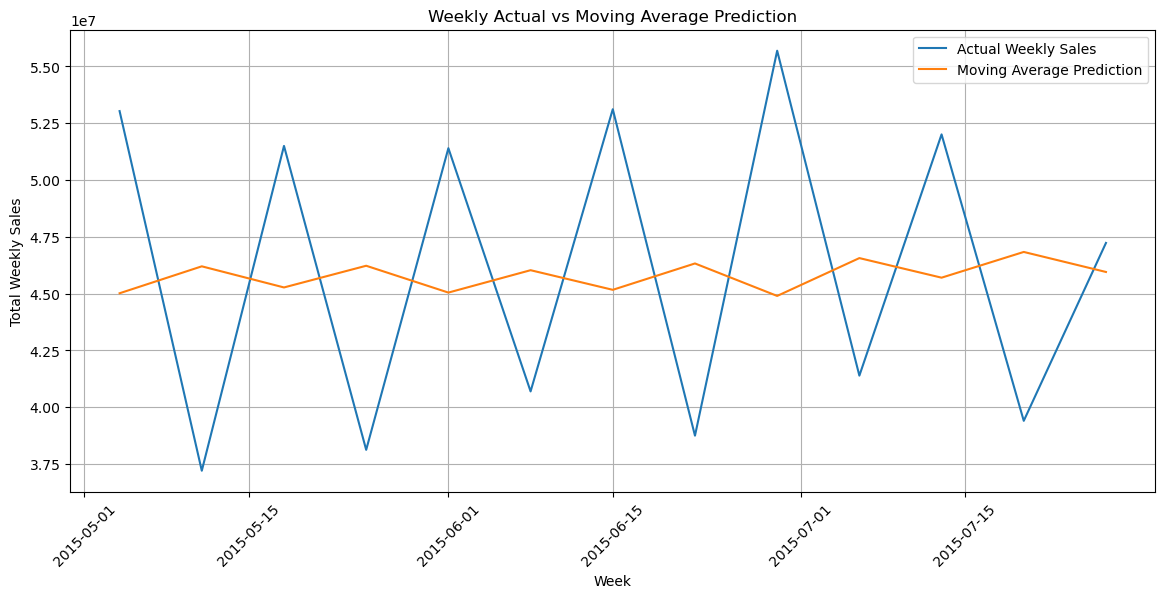

In [81]:
# Weekly actual vs moving average prediction
weekly_ma_plot = weekly_test_df.copy()
weekly_ma_plot['Prediction'] = weekly_ma_plot['rolling_mean_12']

# Aggregate across stores for clearer visualization
weekly_ma_plot_agg = (
    weekly_ma_plot
    .groupby('WeekStartDate', as_index=False)
    .agg({
        'WeeklySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(weekly_ma_plot_agg['WeekStartDate'], weekly_ma_plot_agg['WeeklySales'], label='Actual Weekly Sales')
plt.plot(weekly_ma_plot_agg['WeekStartDate'], weekly_ma_plot_agg['Prediction'], label='Moving Average Prediction')
plt.title('Weekly Actual vs Moving Average Prediction')
plt.xlabel('Week')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

**Plotting actual vs Moving Average prediction for monthly**

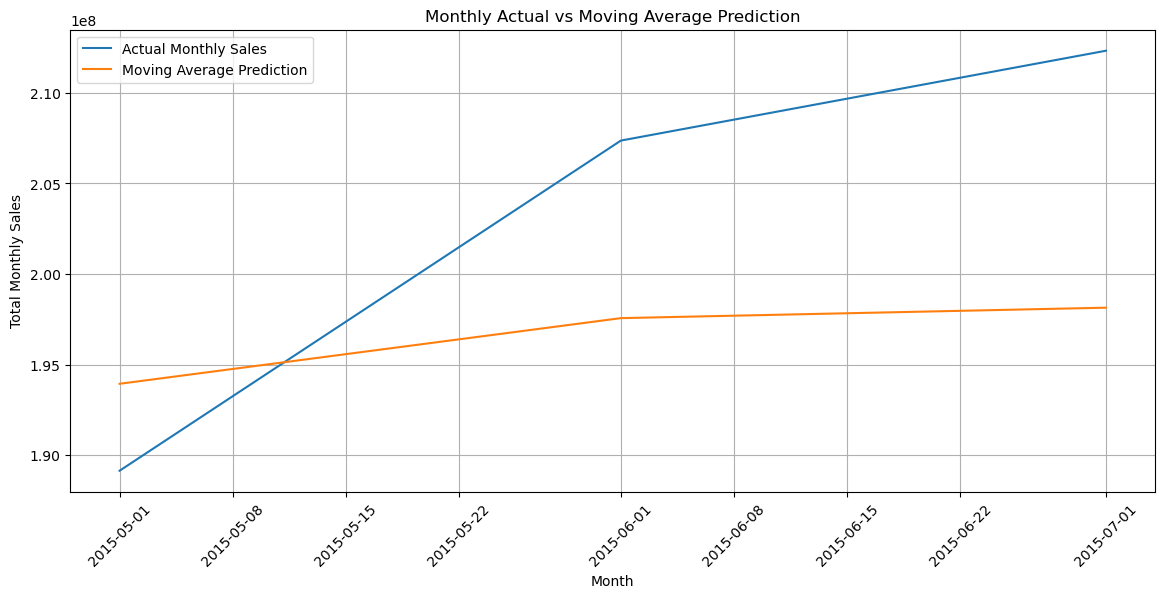

In [82]:
# Monthly actual vs moving average prediction
monthly_ma_plot = monthly_test_df.copy()
monthly_ma_plot['Prediction'] = monthly_ma_plot['rolling_mean_3']

# Aggregate across stores for clearer visualization
monthly_ma_plot_agg = (
    monthly_ma_plot
    .groupby('MonthStartDate', as_index=False)
    .agg({
        'MonthlySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_ma_plot_agg['MonthStartDate'], monthly_ma_plot_agg['MonthlySales'], label='Actual Monthly Sales')
plt.plot(monthly_ma_plot_agg['MonthStartDate'], monthly_ma_plot_agg['Prediction'], label='Moving Average Prediction')
plt.title('Monthly Actual vs Moving Average Prediction')
plt.xlabel('Month')
plt.ylabel('Total Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [83]:
baseline_results_df.to_csv("baseline_moving_average_results.csv", index=False)

print("Saved baseline_moving_average_results.csv")

Saved baseline_moving_average_results.csv


**11. Random Forest Regressor**

This section trains Random Forest Regressor models for weekly and monthly sales forecasting. Unlike Prophet, Random Forest can learn from all stores together using calendar features, store-level features, promotion features, and historical sales features. This makes it suitable for a web-based DSS because a single global model can generate predictions for multiple stores.

In [84]:
from sklearn.ensemble import RandomForestRegressor
#Train weekly Random Forest model
rf_weekly_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_weekly_model.fit(X_weekly_train, y_weekly_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [85]:
#Evaluating wweekly Random Forest
rf_weekly_val_pred = rf_weekly_model.predict(X_weekly_val)
rf_weekly_test_pred = rf_weekly_model.predict(X_weekly_test)

rf_weekly_val_metrics = evaluate_model(y_weekly_val, rf_weekly_val_pred)
rf_weekly_test_metrics = evaluate_model(y_weekly_test, rf_weekly_test_pred)

rf_weekly_results_df = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Weekly',
        'Dataset': 'Validation',
        'MAE': rf_weekly_val_metrics['MAE'],
        'RMSE': rf_weekly_val_metrics['RMSE'],
        'MAPE': rf_weekly_val_metrics['MAPE'],
        'RMSPE': rf_weekly_val_metrics['RMSPE']
    },
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Weekly',
        'Dataset': 'Test',
        'MAE': rf_weekly_test_metrics['MAE'],
        'RMSE': rf_weekly_test_metrics['RMSE'],
        'MAPE': rf_weekly_test_metrics['MAPE'],
        'RMSPE': rf_weekly_test_metrics['RMSPE']
    }
])

display(rf_weekly_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Weekly,Validation,3189.931071,4502.384176,7.782020,10.448091
1,Random Forest,Weekly,Test,2755.087264,4149.092389,6.656944,9.485780


In [86]:
#Training monthly Random Forest model
rf_monthly_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_monthly_model.fit(X_monthly_train, y_monthly_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [87]:
#Evaluating monthly Random Forest
rf_monthly_val_pred = rf_monthly_model.predict(X_monthly_val)
rf_monthly_test_pred = rf_monthly_model.predict(X_monthly_test)

rf_monthly_val_metrics = evaluate_model(y_monthly_val, rf_monthly_val_pred)
rf_monthly_test_metrics = evaluate_model(y_monthly_test, rf_monthly_test_pred)

rf_monthly_results_df = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Monthly',
        'Dataset': 'Validation',
        'MAE': rf_monthly_val_metrics['MAE'],
        'RMSE': rf_monthly_val_metrics['RMSE'],
        'MAPE': rf_monthly_val_metrics['MAPE'],
        'RMSPE': rf_monthly_val_metrics['RMSPE']
    },
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Monthly',
        'Dataset': 'Test',
        'MAE': rf_monthly_test_metrics['MAE'],
        'RMSE': rf_monthly_test_metrics['RMSE'],
        'MAPE': rf_monthly_test_metrics['MAPE'],
        'RMSPE': rf_monthly_test_metrics['RMSPE']
    }
])

display(rf_monthly_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Monthly,Validation,10074.420271,13274.179591,6.093835,8.154674
1,Random Forest,Monthly,Test,9237.142132,12484.180949,5.238849,7.970541


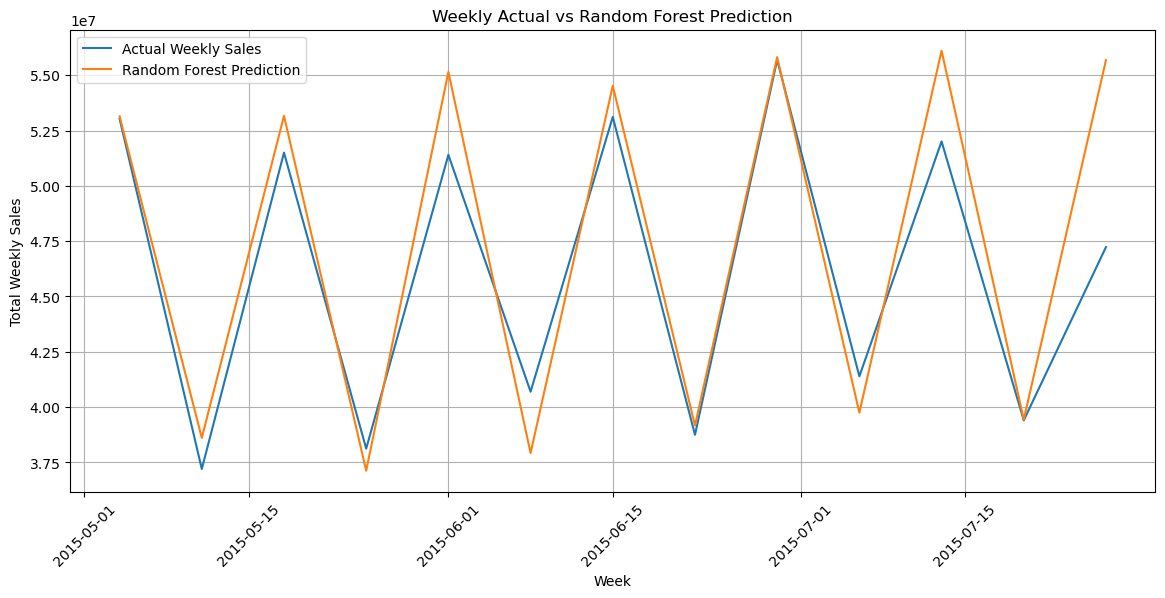

In [88]:
#plotting weekly actual vs predicted
weekly_rf_plot = weekly_test_df[['Store', 'WeekStartDate', 'WeeklySales']].copy()
weekly_rf_plot['Prediction'] = rf_weekly_test_pred

weekly_rf_plot_agg = (
    weekly_rf_plot
    .groupby('WeekStartDate', as_index=False)
    .agg({
        'WeeklySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(weekly_rf_plot_agg['WeekStartDate'], weekly_rf_plot_agg['WeeklySales'], label='Actual Weekly Sales')
plt.plot(weekly_rf_plot_agg['WeekStartDate'], weekly_rf_plot_agg['Prediction'], label='Random Forest Prediction')
plt.title('Weekly Actual vs Random Forest Prediction')
plt.xlabel('Week')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

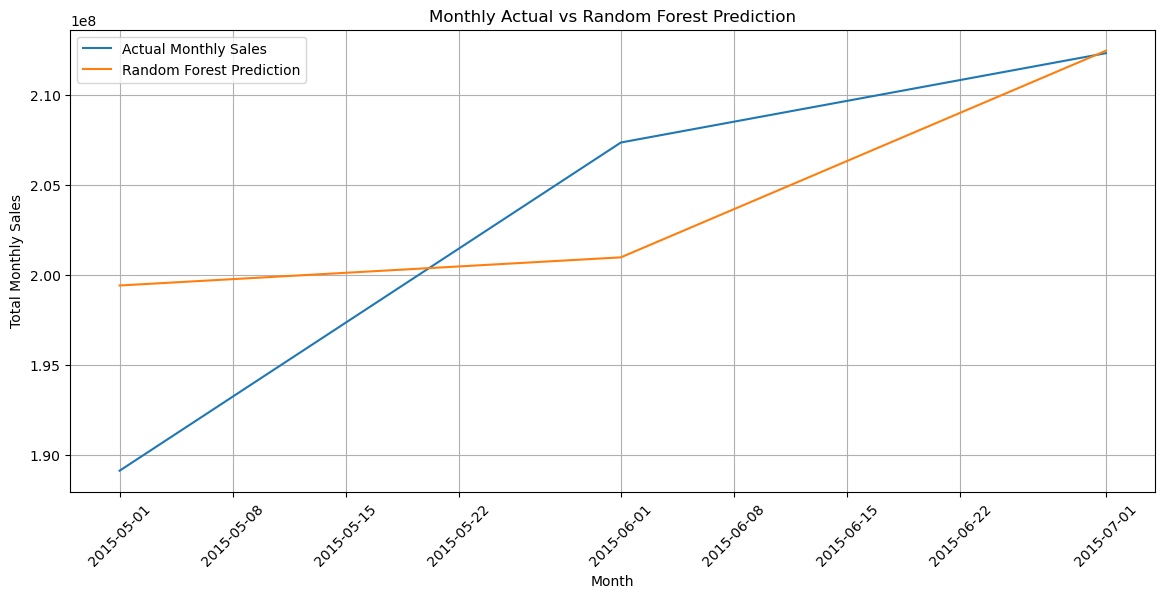

In [89]:
#plotting monthly actual va predicted
monthly_rf_plot = monthly_test_df[['Store', 'MonthStartDate', 'MonthlySales']].copy()
monthly_rf_plot['Prediction'] = rf_monthly_test_pred

monthly_rf_plot_agg = (
    monthly_rf_plot
    .groupby('MonthStartDate', as_index=False)
    .agg({
        'MonthlySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_rf_plot_agg['MonthStartDate'], monthly_rf_plot_agg['MonthlySales'], label='Actual Monthly Sales')
plt.plot(monthly_rf_plot_agg['MonthStartDate'], monthly_rf_plot_agg['Prediction'], label='Random Forest Prediction')
plt.title('Monthly Actual vs Random Forest Prediction')
plt.xlabel('Month')
plt.ylabel('Total Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

,Feature,Importance
24,sales_lag_52,0.302229
29,rolling_mean_12,0.301775
2,PromoDays,0.145234
25,rolling_mean_4,0.072867
21,sales_lag_2,0.061363
32,EMA_8,0.034294
31,EMA_4,0.031709
1,OpenDays,0.010784
22,sales_lag_4,0.005954
10,WeekOfYear,0.004767


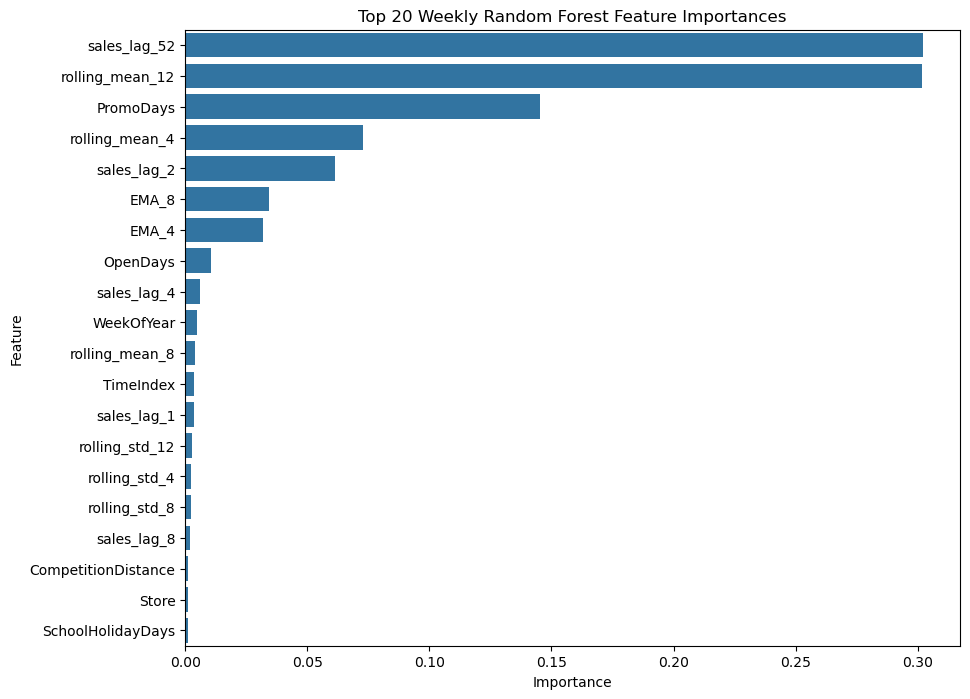

In [90]:
# Extracting features importance from weekly Random Forest model to 
#identify strongly contributed variables
rf_weekly_importance = pd.DataFrame({
    'Feature': weekly_features,
    'Importance': rf_weekly_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(rf_weekly_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=rf_weekly_importance.head(20),
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Weekly Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

,Feature,Importance
22,sales_lag_12,0.633983
28,EMA_6,0.262639
25,rolling_mean_6,0.043039
27,EMA_3,0.019401
19,sales_lag_1,0.013511
9,Month,0.006257
18,TimeIndex,0.004052
2,PromoDays,0.002844
23,rolling_mean_3,0.001736
20,sales_lag_2,0.001734


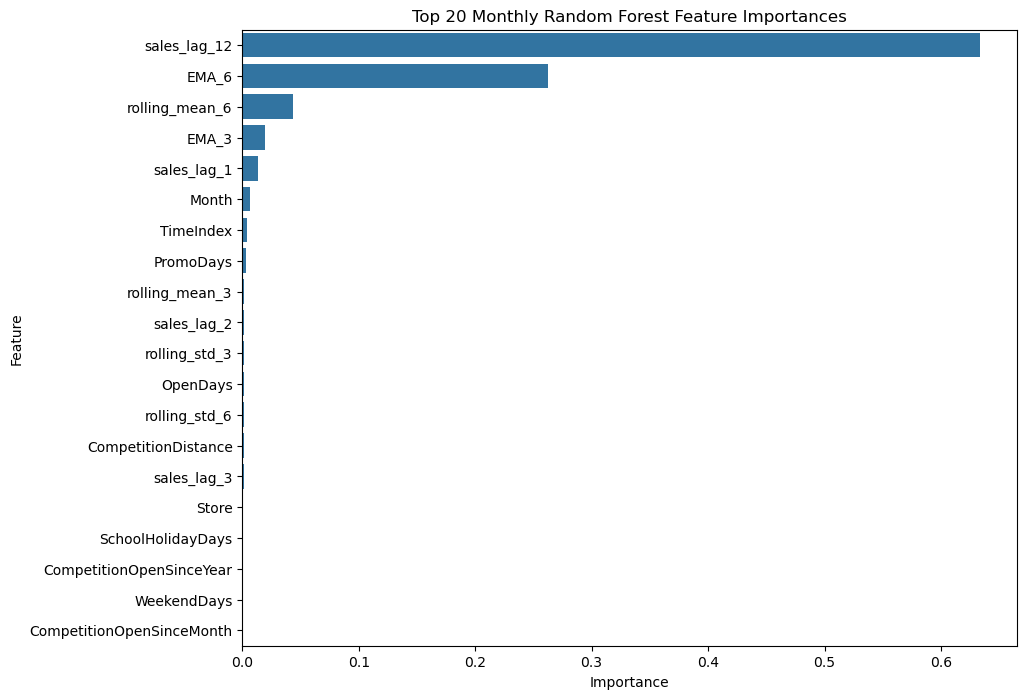

In [91]:
# For monthly
rf_monthly_importance = pd.DataFrame({
    'Feature': monthly_features,
    'Importance': rf_monthly_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(rf_monthly_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=rf_monthly_importance.head(20),
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Monthly Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [92]:
#combine random forest result
rf_results_df = pd.concat(
    [rf_weekly_results_df, rf_monthly_results_df],
    ignore_index=True
)

display(rf_results_df)

rf_results_df.to_csv("random_forest_results.csv", index=False)
rf_weekly_importance.to_csv("rf_weekly_feature_importance.csv", index=False)
rf_monthly_importance.to_csv("rf_monthly_feature_importance.csv", index=False)

print("Saved Random Forest results and feature importance files.")

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Weekly,Validation,3189.931071,4502.384176,7.782020,10.448091
1,Random Forest,Weekly,Test,2755.087264,4149.092389,6.656944,9.485780
2,Random Forest,Monthly,Validation,10074.420271,13274.179591,6.093835,8.154674
3,Random Forest,Monthly,Test,9237.142132,12484.180949,5.238849,7.970541


Saved Random Forest results and feature importance files.


**12. XGBoost Regressor**

This section trains XGBoost Regressor models for weekly and monthly Rossmann sales forecasting. XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree attempts to correct the errors of previous trees. It is often effective for structured tabular datasets and is suitable for integration into a Decision Support System because it can provide strong predictive performance and can later be explained using feature importance and SHAP.

In [93]:
!pip uninstall xgboost -y
!pip install xgboost==2.1.4

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-win_amd64.whl (124.9 MB)


In [94]:
from xgboost import XGBRegressor
# Train weekly XGBoost model
xgb_weekly_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_weekly_model.fit(
    X_weekly_train,
    y_weekly_train,
    eval_set=[(X_weekly_val, y_weekly_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
#Evaluating Weekly XGBoost model
xgb_weekly_val_pred = xgb_weekly_model.predict(X_weekly_val)
xgb_weekly_test_pred = xgb_weekly_model.predict(X_weekly_test)

xgb_weekly_val_metrics = evaluate_model(y_weekly_val, xgb_weekly_val_pred)
xgb_weekly_test_metrics = evaluate_model(y_weekly_test, xgb_weekly_test_pred)

xgb_weekly_results_df = pd.DataFrame([
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Weekly',
        'Dataset': 'Validation',
        'MAE': xgb_weekly_val_metrics['MAE'],
        'RMSE': xgb_weekly_val_metrics['RMSE'],
        'MAPE': xgb_weekly_val_metrics['MAPE'],
        'RMSPE': xgb_weekly_val_metrics['RMSPE']
    },
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Weekly',
        'Dataset': 'Test',
        'MAE': xgb_weekly_test_metrics['MAE'],
        'RMSE': xgb_weekly_test_metrics['RMSE'],
        'MAPE': xgb_weekly_test_metrics['MAPE'],
        'RMSPE': xgb_weekly_test_metrics['RMSPE']
    }
])

display(xgb_weekly_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Weekly,Validation,2778.049805,3963.514980,6.862316,9.281275
1,XGBoost,Weekly,Test,2167.755859,3182.837728,5.289445,7.443018


In [96]:
#Train monthly XGBoost model
xgb_monthly_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_monthly_model.fit(
    X_monthly_train,
    y_monthly_train,
    eval_set=[(X_monthly_val, y_monthly_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [97]:
#Evaluating monthly XGBoost model
xgb_monthly_val_pred = xgb_monthly_model.predict(X_monthly_val)
xgb_monthly_test_pred = xgb_monthly_model.predict(X_monthly_test)

xgb_monthly_val_metrics = evaluate_model(y_monthly_val, xgb_monthly_val_pred)
xgb_monthly_test_metrics = evaluate_model(y_monthly_test, xgb_monthly_test_pred)

xgb_monthly_results_df = pd.DataFrame([
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Monthly',
        'Dataset': 'Validation',
        'MAE': xgb_monthly_val_metrics['MAE'],
        'RMSE': xgb_monthly_val_metrics['RMSE'],
        'MAPE': xgb_monthly_val_metrics['MAPE'],
        'RMSPE': xgb_monthly_val_metrics['RMSPE']
    },
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Monthly',
        'Dataset': 'Test',
        'MAE': xgb_monthly_test_metrics['MAE'],
        'RMSE': xgb_monthly_test_metrics['RMSE'],
        'MAPE': xgb_monthly_test_metrics['MAPE'],
        'RMSPE': xgb_monthly_test_metrics['RMSPE']
    }
])

display(xgb_monthly_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Monthly,Validation,10112.019531,12875.818576,5.902924,7.223632
1,XGBoost,Monthly,Test,8768.959961,11384.133520,5.022496,6.471465


**Plotting actual vs XGBoost prediction**

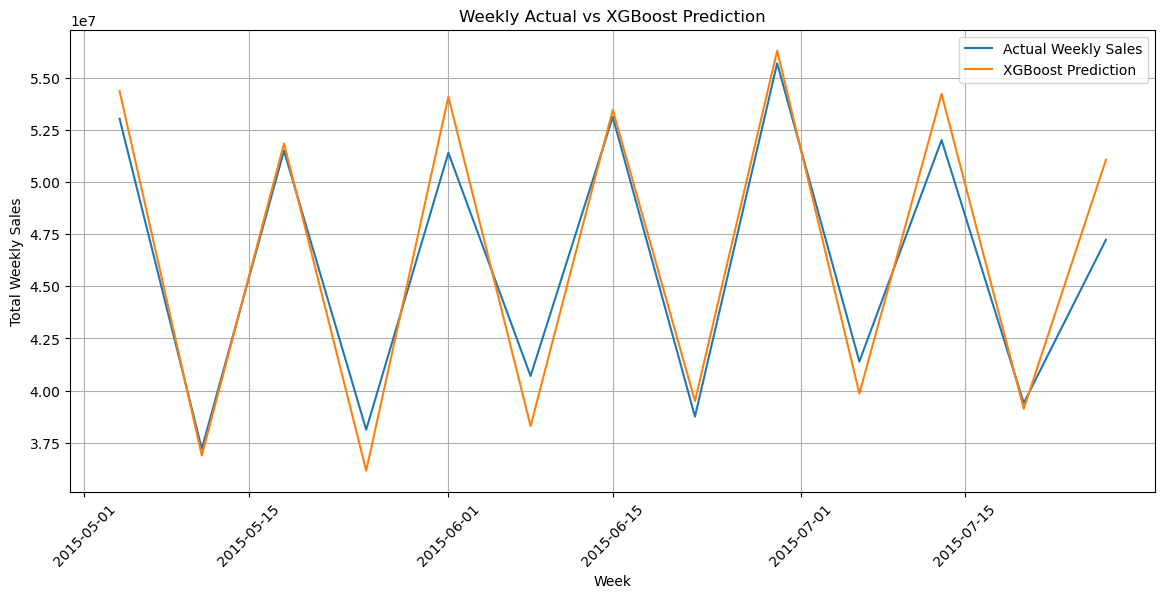

In [98]:
#plotting weekly actual vs prediction
weekly_xgb_plot = weekly_test_df[['Store', 'WeekStartDate', 'WeeklySales']].copy()
weekly_xgb_plot['Prediction'] = xgb_weekly_test_pred

weekly_xgb_plot_agg = (
    weekly_xgb_plot
    .groupby('WeekStartDate', as_index=False)
    .agg({
        'WeeklySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(weekly_xgb_plot_agg['WeekStartDate'], weekly_xgb_plot_agg['WeeklySales'], label='Actual Weekly Sales')
plt.plot(weekly_xgb_plot_agg['WeekStartDate'], weekly_xgb_plot_agg['Prediction'], label='XGBoost Prediction')
plt.title('Weekly Actual vs XGBoost Prediction')
plt.xlabel('Week')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

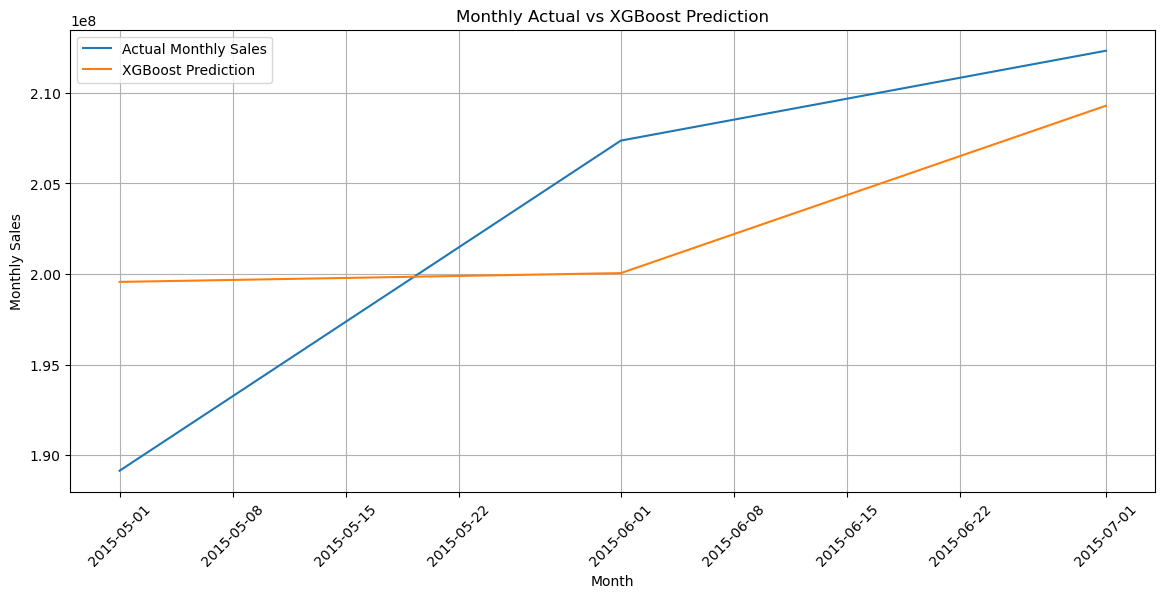

In [99]:
#plotting monthly actual vs prediction
monthly_xgb_plot = monthly_test_df[['Store', 'MonthStartDate', 'MonthlySales']].copy()
monthly_xgb_plot['Prediction'] = xgb_monthly_test_pred

monthly_xgb_plot_agg = (
    monthly_xgb_plot
    .groupby('MonthStartDate', as_index=False)
    .agg({
        'MonthlySales': 'sum',
        'Prediction': 'sum'
    })
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_xgb_plot_agg['MonthStartDate'], monthly_xgb_plot_agg['MonthlySales'], label='Actual Monthly Sales')
plt.plot(monthly_xgb_plot_agg['MonthStartDate'], monthly_xgb_plot_agg['Prediction'], label='XGBoost Prediction')
plt.title('Monthly Actual vs XGBoost Prediction')
plt.xlabel('Month')
plt.ylabel('Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

,Feature,Importance
29,rolling_mean_12,0.248363
24,sales_lag_52,0.173363
2,PromoDays,0.137526
32,EMA_8,0.104834
27,rolling_mean_8,0.082197
25,rolling_mean_4,0.074292
31,EMA_4,0.055122
21,sales_lag_2,0.047380
1,OpenDays,0.012450
22,sales_lag_4,0.005299


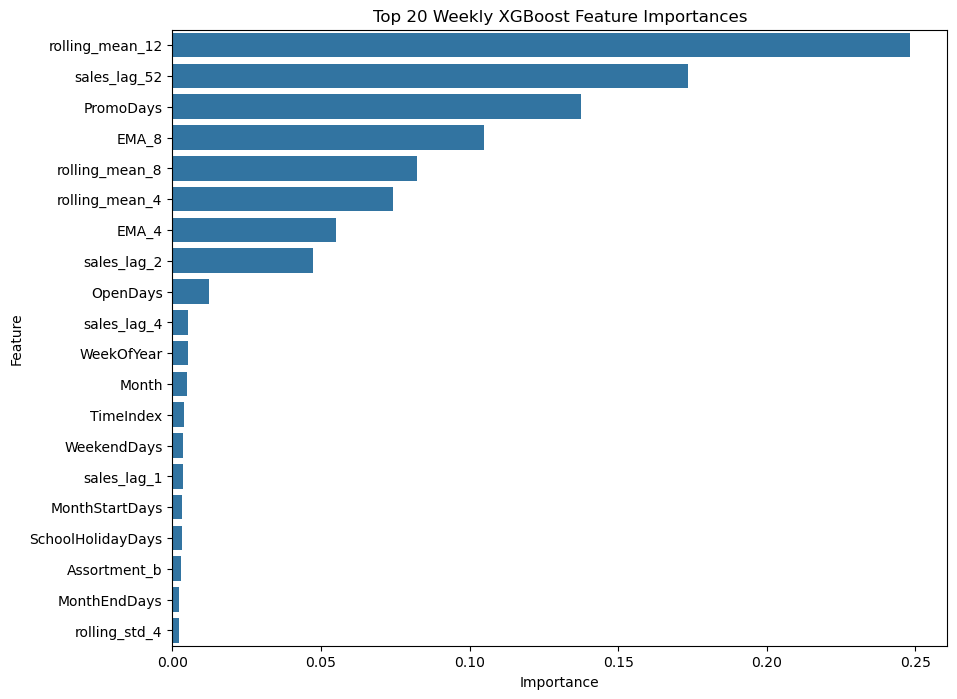

In [100]:
#XGBoost feature importance for weekly
xgb_weekly_importance = pd.DataFrame({
    'Feature': weekly_features,
    'Importance': xgb_weekly_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(xgb_weekly_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=xgb_weekly_importance.head(20),
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Weekly XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

,Feature,Importance
28,EMA_6,0.365901
22,sales_lag_12,0.242635
25,rolling_mean_6,0.162384
27,EMA_3,0.132072
19,sales_lag_1,0.026094
18,TimeIndex,0.010700
9,Month,0.008850
23,rolling_mean_3,0.008290
34,Assortment_b,0.004894
10,Quarter,0.004179


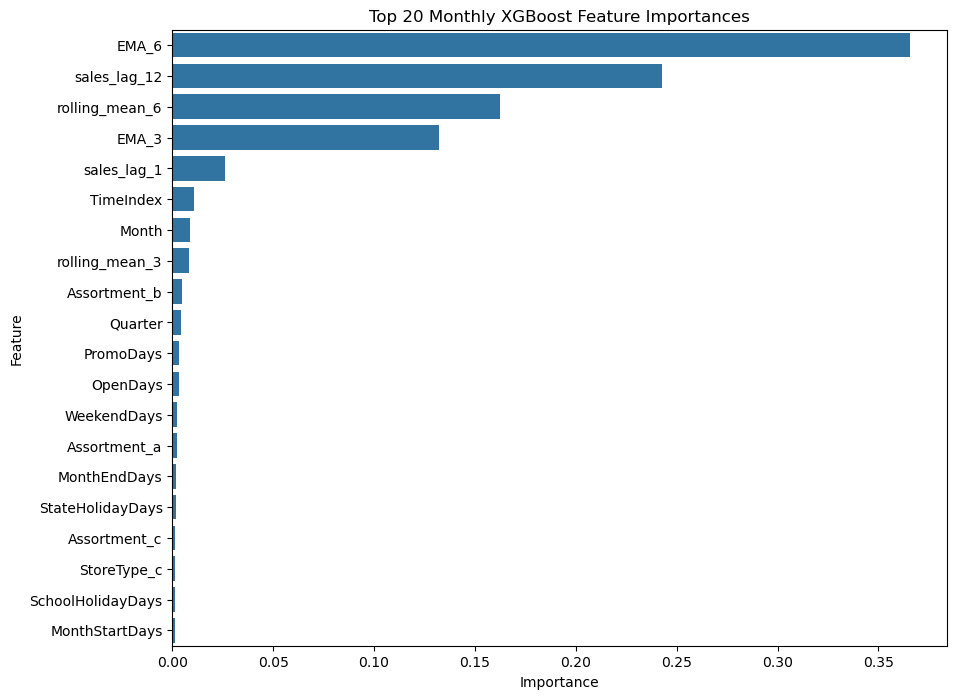

In [101]:
#XGBoost features importance for monthly
xgb_monthly_importance = pd.DataFrame({
    'Feature': monthly_features,
    'Importance': xgb_monthly_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(xgb_monthly_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=xgb_monthly_importance.head(20),
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Monthly XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [102]:
#combining XGBoost result
xgb_results_df = pd.concat(
    [xgb_weekly_results_df, xgb_monthly_results_df],
    ignore_index=True
)

display(xgb_results_df)

xgb_results_df.to_csv("xgboost_results.csv", index=False)
xgb_weekly_importance.to_csv("xgb_weekly_feature_importance.csv", index=False)
xgb_monthly_importance.to_csv("xgb_monthly_feature_importance.csv", index=False)

print("Saved XGBoost results and feature importance files.")

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Weekly,Validation,2778.049805,3963.514980,6.862316,9.281275
1,XGBoost,Weekly,Test,2167.755859,3182.837728,5.289445,7.443018
2,XGBoost,Monthly,Validation,10112.019531,12875.818576,5.902924,7.223632
3,XGBoost,Monthly,Test,8768.959961,11384.133520,5.022496,6.471465


Saved XGBoost results and feature importance files.


**13. Final Model Comparison and Model Selection**

This section compares the performance of the baseline, Prophet, Random Forest, and XGBoost models. The aim is to select the most suitable forecasting model for the Decision Support System based on predictive performance, explainability, scalability, and integration suitability.

In [103]:
# creating final comparison table
# Select best Moving Average baseline results
best_weekly_ma = weekly_ma_results_df.sort_values('RMSE').iloc[0]
best_monthly_ma = monthly_ma_results_df.sort_values('RMSE').iloc[0]

# Select Random Forest test results
rf_weekly_test_result = rf_weekly_results_df[rf_weekly_results_df['Dataset'] == 'Test'].iloc[0]
rf_monthly_test_result = rf_monthly_results_df[rf_monthly_results_df['Dataset'] == 'Test'].iloc[0]

# Select XGBoost test results
xgb_weekly_test_result = xgb_weekly_results_df[xgb_weekly_results_df['Dataset'] == 'Test'].iloc[0]
xgb_monthly_test_result = xgb_monthly_results_df[xgb_monthly_results_df['Dataset'] == 'Test'].iloc[0]

# Build final comparison table
final_results = [
    {
        'Model': best_weekly_ma['Model'],
        'Forecast Type': 'Weekly',
        'Scope': 'All Stores',
        'MAE': best_weekly_ma['MAE'],
        'RMSE': best_weekly_ma['RMSE'],
        'MAPE': best_weekly_ma['MAPE'],
        'RMSPE': best_weekly_ma['RMSPE']
    },
    {
        'Model': best_monthly_ma['Model'],
        'Forecast Type': 'Monthly',
        'Scope': 'All Stores',
        'MAE': best_monthly_ma['MAE'],
        'RMSE': best_monthly_ma['RMSE'],
        'MAPE': best_monthly_ma['MAPE'],
        'RMSPE': best_monthly_ma['RMSPE']
    },
   
    
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Weekly',
        'Scope': 'All Stores',
        'MAE': rf_weekly_test_result['MAE'],
        'RMSE': rf_weekly_test_result['RMSE'],
        'MAPE': rf_weekly_test_result['MAPE'],
        'RMSPE': rf_weekly_test_result['RMSPE']
    },
    {
        'Model': 'Random Forest',
        'Forecast Type': 'Monthly',
        'Scope': 'All Stores',
        'MAE': rf_monthly_test_result['MAE'],
        'RMSE': rf_monthly_test_result['RMSE'],
        'MAPE': rf_monthly_test_result['MAPE'],
        'RMSPE': rf_monthly_test_result['RMSPE']
    },
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Weekly',
        'Scope': 'All Stores',
        'MAE': xgb_weekly_test_result['MAE'],
        'RMSE': xgb_weekly_test_result['RMSE'],
        'MAPE': xgb_weekly_test_result['MAPE'],
        'RMSPE': xgb_weekly_test_result['RMSPE']
    },
    {
        'Model': 'XGBoost',
        'Forecast Type': 'Monthly',
        'Scope': 'All Stores',
        'MAE': xgb_monthly_test_result['MAE'],
        'RMSE': xgb_monthly_test_result['RMSE'],
        'MAPE': xgb_monthly_test_result['MAPE'],
        'RMSPE': xgb_monthly_test_result['RMSPE']
    }
]

final_results_df = pd.DataFrame(final_results)

# Round for cleaner display
final_results_df[['MAE', 'RMSE', 'MAPE', 'RMSPE']] = final_results_df[['MAE', 'RMSE', 'MAPE', 'RMSPE']].round(3)

display(final_results_df)

,Model,Forecast Type,Scope,MAE,RMSE,MAPE,RMSPE
0,Moving Average 12 Weeks,Weekly,All Stores,6485.035,7511.622,16.499,19.266
1,Moving Average 3 Months,Monthly,All Stores,10288.421,14161.568,5.617,8.311
2,Random Forest,Weekly,All Stores,2755.087,4149.092,6.657,9.486
3,Random Forest,Monthly,All Stores,9237.142,12484.181,5.239,7.971
4,XGBoost,Weekly,All Stores,2167.756,3182.838,5.289,7.443
5,XGBoost,Monthly,All Stores,8768.960,11384.134,5.022,6.471


In [105]:
all_store_results_df = final_results_df[final_results_df['Scope'] == 'All Stores'].copy()
display(all_store_results_df)

,Model,Forecast Type,Scope,MAE,RMSE,MAPE,RMSPE
0,Moving Average 12 Weeks,Weekly,All Stores,6485.035,7511.622,16.499,19.266
1,Moving Average 3 Months,Monthly,All Stores,10288.421,14161.568,5.617,8.311
2,Random Forest,Weekly,All Stores,2755.087,4149.092,6.657,9.486
3,Random Forest,Monthly,All Stores,9237.142,12484.181,5.239,7.971
4,XGBoost,Weekly,All Stores,2167.756,3182.838,5.289,7.443
5,XGBoost,Monthly,All Stores,8768.960,11384.134,5.022,6.471


In [106]:
#Identifying best weekly and monthly model for all-store
best_weekly_model = (
    all_store_results_df[all_store_results_df['Forecast Type'] == 'Weekly']
    .sort_values('RMSE')
    .iloc[0]
)

best_monthly_model = (
    all_store_results_df[all_store_results_df['Forecast Type'] == 'Monthly']
    .sort_values('RMSE')
    .iloc[0]
)

print("Best weekly model:")
display(best_weekly_model)

print("Best monthly model:")
display(best_monthly_model)

Best weekly model:


Model               XGBoost
Forecast Type        Weekly
Scope            All Stores
MAE                2167.756
RMSE               3182.838
MAPE                  5.289
RMSPE                 7.443
Name: 4, dtype: object

Best monthly model:


Model               XGBoost
Forecast Type       Monthly
Scope            All Stores
MAE                 8768.96
RMSE              11384.134
MAPE                  5.022
RMSPE                 6.471
Name: 5, dtype: object

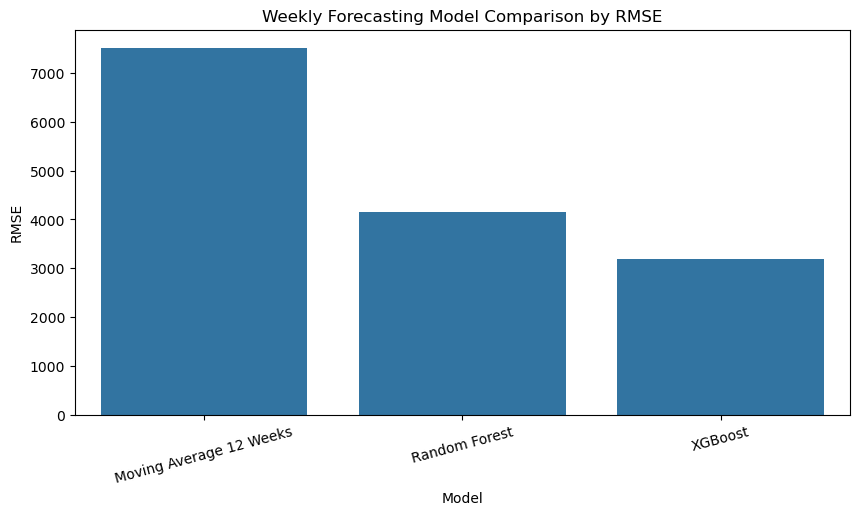

In [107]:
# visual comparison of model(weekly)
weekly_comparison = all_store_results_df[
    all_store_results_df['Forecast Type'] == 'Weekly'
].copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_comparison, x='Model', y='RMSE')
plt.title('Weekly Forecasting Model Comparison by RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

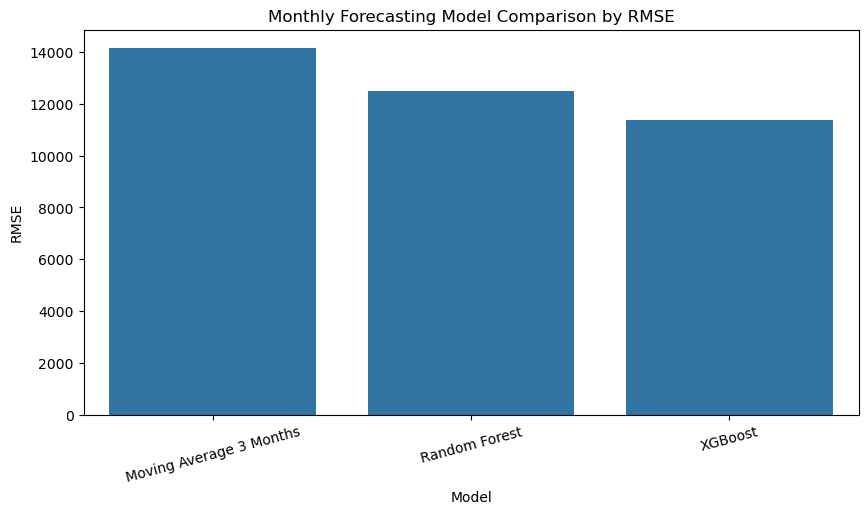

In [108]:
#visual comparison of model(monthly)
monthly_comparison = all_store_results_df[
    all_store_results_df['Forecast Type'] == 'Monthly'
].copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_comparison, x='Model', y='RMSE')
plt.title('Monthly Forecasting Model Comparison by RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

In [109]:
#saving final comparison result
final_results_df.to_csv("final_model_comparison_all_models.csv", index=False)
all_store_results_df.to_csv("final_model_comparison_all_store_models.csv", index=False)

print("Saved final model comparison tables.")

Saved final model comparison tables.


**14. Explainability with Feature Importance and SHAP**

This section explains the selected XGBoost forecasting models using feature importance and SHAP values. Feature importance provides a global explanation of which variables generally influence the model, while SHAP provides both global and local explanations. This supports the explainability requirement of the proposed Decision Support System.

In [110]:
import shap
# Use sample data for SHAP to reduce computation time
X_weekly_shap_sample = X_weekly_test.sample(
    n=min(1000, len(X_weekly_test)),
    random_state=42
)

X_monthly_shap_sample = X_monthly_test.sample(
    n=min(1000, len(X_monthly_test)),
    random_state=42
)

print("Weekly SHAP sample shape:", X_weekly_shap_sample.shape)
print("Monthly SHAP sample shape:", X_monthly_shap_sample.shape)

Weekly SHAP sample shape: (1000, 44)
Monthly SHAP sample shape: (1000, 40)


**Creating SHAP explainers for XGBoost**

In [111]:
# Create SHAP explainers for the trained XGBoost models
weekly_explainer = shap.TreeExplainer(xgb_weekly_model)
monthly_explainer = shap.TreeExplainer(xgb_monthly_model)

# Calculate SHAP values
weekly_shap_values = weekly_explainer.shap_values(X_weekly_shap_sample)
monthly_shap_values = monthly_explainer.shap_values(X_monthly_shap_sample)

print("Weekly SHAP values shape:", np.array(weekly_shap_values).shape)
print("Monthly SHAP values shape:", np.array(monthly_shap_values).shape)

Weekly SHAP values shape: (1000, 44)
Monthly SHAP values shape: (1000, 40)


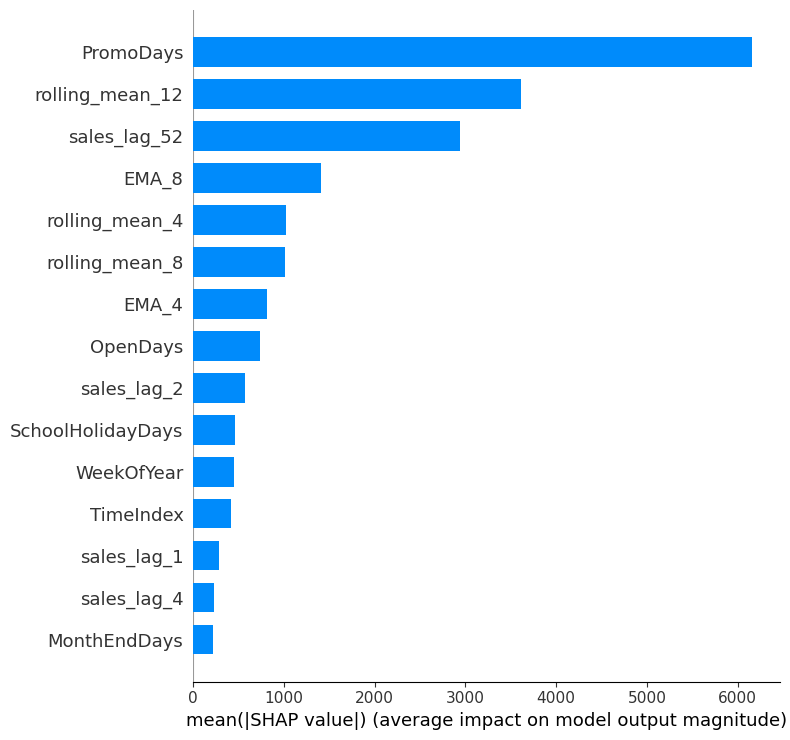

In [112]:
# weekly SHAP global summary plot
shap.summary_plot(
    weekly_shap_values,
    X_weekly_shap_sample,
    plot_type="bar",
    max_display=15
)

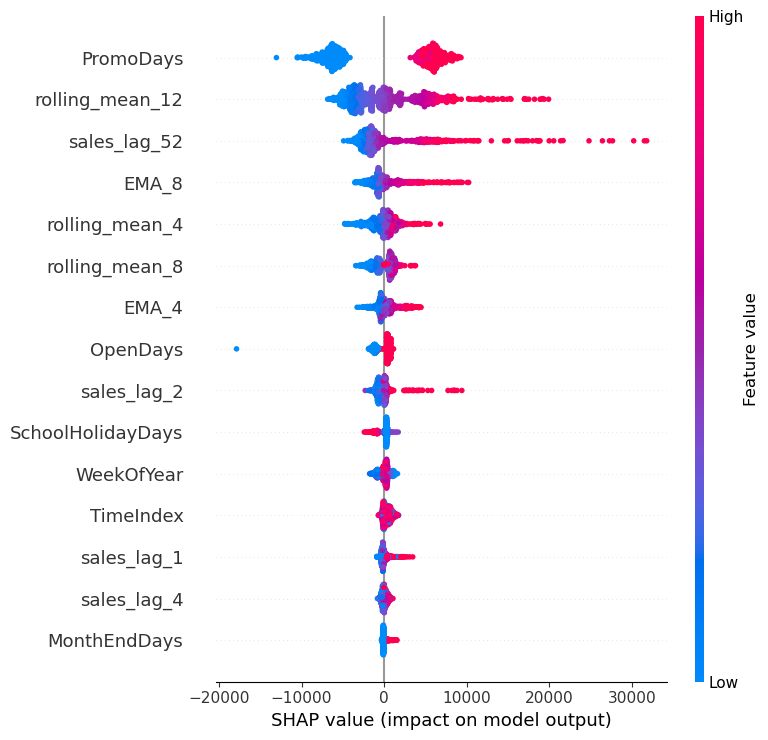

In [113]:
shap.summary_plot(
    weekly_shap_values,
    X_weekly_shap_sample,
    max_display=15
)

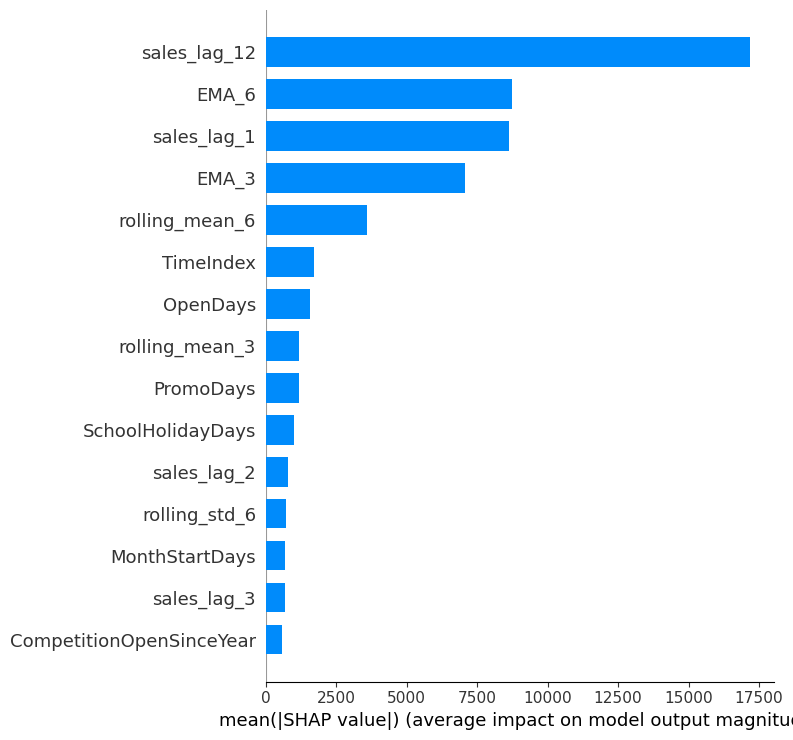

In [114]:
#Monthly SHAP global summary plot
shap.summary_plot(
    monthly_shap_values,
    X_monthly_shap_sample,
    plot_type="bar",
    max_display=15
)

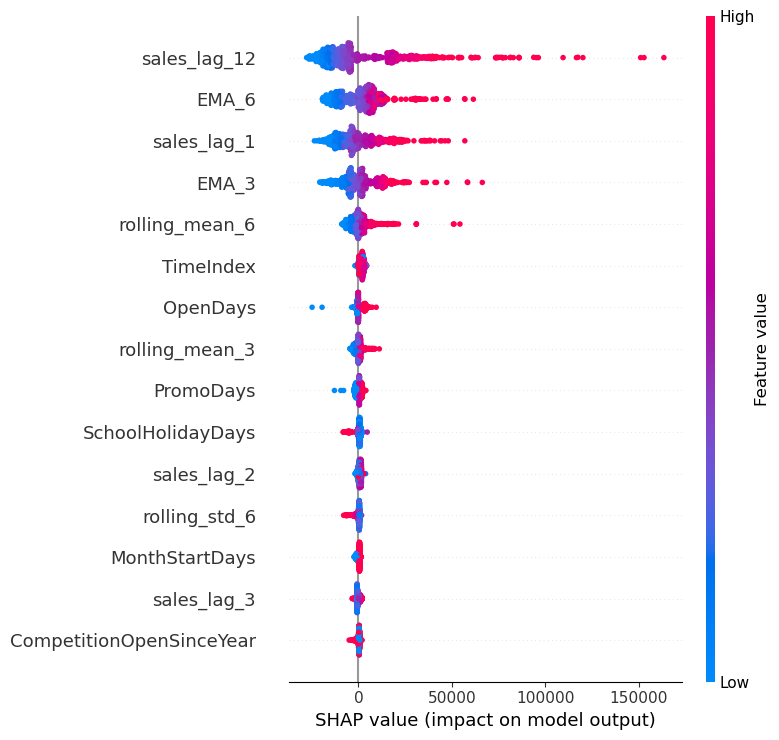

In [115]:
shap.summary_plot(
    monthly_shap_values,
    X_monthly_shap_sample,
    max_display=15
)

In [116]:
#local explanation for one weekly forecast
# Choose one weekly test instance
weekly_instance_index = X_weekly_shap_sample.index[0]

weekly_instance = X_weekly_test.loc[[weekly_instance_index]]
weekly_actual = y_weekly_test.loc[weekly_instance_index]
weekly_prediction = xgb_weekly_model.predict(weekly_instance)[0]

print("Weekly instance index:", weekly_instance_index)
print("Actual weekly sales:", weekly_actual)
print("Predicted weekly sales:", weekly_prediction)

Weekly instance index: 52748
Actual weekly sales: 39971
Predicted weekly sales: 42151.99


In [117]:
#calulating the SHAP explanation for this one row
weekly_instance_shap_values = weekly_explainer.shap_values(weekly_instance)

# Create local explanation table
weekly_local_explanation = pd.DataFrame({
    'Feature': weekly_instance.columns,
    'Feature Value': weekly_instance.iloc[0].values,
    'SHAP Value': weekly_instance_shap_values[0]
})

weekly_local_explanation['Effect'] = np.where(
    weekly_local_explanation['SHAP Value'] > 0,
    'Increases prediction',
    'Decreases prediction'
)

weekly_local_explanation = weekly_local_explanation.reindex(
    weekly_local_explanation['SHAP Value'].abs().sort_values(ascending=False).index
)

display(weekly_local_explanation.head(15))

,Feature,Feature Value,SHAP Value,Effect
2,PromoDays,4.000000,4851.672363,Increases prediction
24,sales_lag_52,32247.000000,-1621.545776,Decreases prediction
1,OpenDays,5.000000,-1243.307007,Decreases prediction
3,SchoolHolidayDays,4.000000,-844.703186,Decreases prediction
32,EMA_8,37401.913725,-748.263000,Decreases prediction
27,rolling_mean_8,37370.875000,646.332764,Increases prediction
19,TimeIndex,102.000000,604.332092,Increases prediction
29,rolling_mean_12,38244.250000,-599.258423,Decreases prediction
10,WeekOfYear,23.000000,408.465332,Increases prediction
5,MonthStartDays,1.000000,316.249664,Increases prediction


In [118]:
#local explanation for monthly forecast
# Choose one monthly test instance
monthly_instance_index = X_monthly_shap_sample.index[0]

monthly_instance = X_monthly_test.loc[[monthly_instance_index]]
monthly_actual = y_monthly_test.loc[monthly_instance_index]
monthly_prediction = xgb_monthly_model.predict(monthly_instance)[0]

print("Monthly instance index:", monthly_instance_index)
print("Actual monthly sales:", monthly_actual)
print("Predicted monthly sales:", monthly_prediction)

Monthly instance index: 6316
Actual monthly sales: 160502
Predicted monthly sales: 171828.62


In [119]:
monthly_instance_shap_values = monthly_explainer.shap_values(monthly_instance)

# Create local explanation table
monthly_local_explanation = pd.DataFrame({
    'Feature': monthly_instance.columns,
    'Feature Value': monthly_instance.iloc[0].values,
    'SHAP Value': monthly_instance_shap_values[0]
})

monthly_local_explanation['Effect'] = np.where(
    monthly_local_explanation['SHAP Value'] > 0,
    'Increases prediction',
    'Decreases prediction'
)

monthly_local_explanation = monthly_local_explanation.reindex(
    monthly_local_explanation['SHAP Value'].abs().sort_values(ascending=False).index
)

display(monthly_local_explanation.head(15))

,Feature,Feature Value,SHAP Value,Effect
22,sales_lag_12,164362.000000,-8041.553223,Decreases prediction
19,sales_lag_1,168228.000000,-2611.629639,Decreases prediction
28,EMA_6,168394.604215,2490.305908,Increases prediction
18,TimeIndex,29.000000,2482.911377,Increases prediction
2,PromoDays,10.000000,-1622.898926,Decreases prediction
26,rolling_std_6,22777.230520,-1307.392944,Decreases prediction
5,MonthStartDays,0.000000,-1231.725830,Decreases prediction
38,"PromoInterval_Mar,Jun,Sept,Dec",1.000000,1084.335571,Increases prediction
17,Promo2SinceYear,2012.000000,991.254639,Increases prediction
6,MonthEndDays,0.000000,933.310669,Increases prediction


**converting SHAP local explanation into DSS-style messages**

In [120]:
def create_dss_explanation(local_explanation_df, top_n=3):
    
    top_features = local_explanation_df.head(top_n)
    
    messages = []
    
    for _, row in top_features.iterrows():
        feature = row['Feature']
        value = row['Feature Value']
        shap_value = row['SHAP Value']
        effect = row['Effect']
        
        direction = "increased" if shap_value > 0 else "reduced"
        
        message = f"{feature} = {value} {direction} the forecast."
        messages.append(message)
    
    return messages

In [121]:
weekly_dss_messages = create_dss_explanation(weekly_local_explanation, top_n=5)
monthly_dss_messages = create_dss_explanation(monthly_local_explanation, top_n=5)

print("Weekly DSS explanation messages:")
for msg in weekly_dss_messages:
    print("-", msg)

print("\nMonthly DSS explanation messages:")
for msg in monthly_dss_messages:
    print("-", msg)

Weekly DSS explanation messages:
- PromoDays = 4.0 increased the forecast.
- sales_lag_52 = 32247.0 reduced the forecast.
- OpenDays = 5.0 reduced the forecast.
- SchoolHolidayDays = 4.0 reduced the forecast.
- EMA_8 = 37401.91372480588 reduced the forecast.

Monthly DSS explanation messages:
- sales_lag_12 = 164362.0 reduced the forecast.
- sales_lag_1 = 168228.0 reduced the forecast.
- EMA_6 = 168394.60421540763 increased the forecast.
- TimeIndex = 29.0 increased the forecast.
- PromoDays = 10.0 reduced the forecast.


In [122]:
weekly_local_explanation.to_csv("weekly_local_shap_explanation.csv", index=False)
monthly_local_explanation.to_csv("monthly_local_shap_explanation.csv", index=False)

print("Saved local SHAP explanation tables.")

Saved local SHAP explanation tables.


**15. DSS Forecast Output Preparation**

This section prepares forecast outputs in a format suitable for the proposed Decision Support System. Instead of returning only predicted sales values, the output includes store, period, forecast type, predicted sales, important positive factors, important negative factors, and a business-support message.

In [123]:
# creating readable feature names
feature_name_map = {
    'PromoDays': 'promotion activity',
    'OpenDays': 'number of open days',
    'SchoolHolidayDays': 'school holiday period',
    'StateHolidayDays': 'state holiday period',
    'WeekendDays': 'weekend days',
    'MonthStartDays': 'month-start timing',
    'MonthEndDays': 'month-end timing',
    'sales_lag_1': 'previous period sales',
    'sales_lag_2': 'sales two periods ago',
    'sales_lag_3': 'sales three periods ago',
    'sales_lag_4': 'sales four weeks ago',
    'sales_lag_8': 'sales eight weeks ago',
    'sales_lag_12': 'same period last year',
    'sales_lag_52': 'same week last year',
    'rolling_mean_3': 'recent 3-period average demand',
    'rolling_mean_4': 'recent 4-week average demand',
    'rolling_mean_6': 'recent 6-period average demand',
    'rolling_mean_8': 'recent 8-week average demand',
    'rolling_mean_12': 'recent 12-week average demand',
    'rolling_std_3': 'recent 3-period demand volatility',
    'rolling_std_4': 'recent 4-week demand volatility',
    'rolling_std_6': 'recent 6-period demand volatility',
    'rolling_std_8': 'recent 8-week demand volatility',
    'rolling_std_12': 'recent 12-week demand volatility',
    'EMA_3': 'recent 3-period weighted demand trend',
    'EMA_4': 'recent 4-week weighted demand trend',
    'EMA_6': 'recent 6-period weighted demand trend',
    'EMA_8': 'recent 8-week weighted demand trend',
    'TimeIndex': 'time progression',
    'Month': 'month of year',
    'WeekOfYear': 'week of year',
    'Quarter': 'quarter of year',
    'CompetitionDistance': 'competition distance',
    'Promo2': 'long-term promotion participation'
}

In [124]:
#creating function for explanation factors
def extract_positive_negative_factors(local_explanation_df, top_n=3):
    """
    Extracts top positive and negative SHAP factors from a local explanation table.
    """
    positive = (
        local_explanation_df[local_explanation_df['SHAP Value'] > 0]
        .sort_values('SHAP Value', ascending=False)
        .head(top_n)
    )
    
    negative = (
        local_explanation_df[local_explanation_df['SHAP Value'] < 0]
        .sort_values('SHAP Value', ascending=True)
        .head(top_n)
    )
    
    positive_factors = []
    negative_factors = []
    
    for _, row in positive.iterrows():
        readable_name = feature_name_map.get(row['Feature'], row['Feature'])
        positive_factors.append(readable_name)
    
    for _, row in negative.iterrows():
        readable_name = feature_name_map.get(row['Feature'], row['Feature'])
        negative_factors.append(readable_name)
    
    return positive_factors, negative_factors

In [125]:
#creating business message function
def create_business_message(predicted_sales, positive_factors, negative_factors, forecast_type):
    """
    Creates a simple DSS-style business message based on forecast and explanation factors.
    """
    message_parts = []
    
    message_parts.append(
        f"{forecast_type} demand forecast is {predicted_sales:,.0f} sales units."
    )
    
    if len(positive_factors) > 0:
        message_parts.append(
            "Main factors increasing the forecast: " + ", ".join(positive_factors) + "."
        )
    
    if len(negative_factors) > 0:
        message_parts.append(
            "Main factors reducing the forecast: " + ", ".join(negative_factors) + "."
        )
    
    # Simple decision-support recommendation
    if predicted_sales > 50000 and forecast_type == "Weekly":
        message_parts.append(
            "Recommendation: prepare higher stock and staffing for the upcoming week."
        )
    elif predicted_sales > 180000 and forecast_type == "Monthly":
        message_parts.append(
            "Recommendation: plan sufficient monthly inventory and monitor promotional demand."
        )
    else:
        message_parts.append(
            "Recommendation: maintain normal stock planning but monitor demand changes."
        )
    
    return " ".join(message_parts)

In [126]:
# Reuse the weekly local explanation from Section 14
#create one weekly DSS output row
weekly_positive_factors, weekly_negative_factors = extract_positive_negative_factors(
    weekly_local_explanation,
    top_n=3
)

weekly_dss_message = create_business_message(
    predicted_sales=weekly_prediction,
    positive_factors=weekly_positive_factors,
    negative_factors=weekly_negative_factors,
    forecast_type="Weekly"
)

weekly_dss_output = pd.DataFrame([{
    'Store': weekly_test_df.loc[weekly_instance_index, 'Store'],
    'Period': weekly_test_df.loc[weekly_instance_index, 'WeekStartDate'],
    'Forecast Type': 'Weekly',
    'Predicted Sales': round(weekly_prediction, 2),
    'Actual Sales': round(weekly_actual, 2),
    'Important Positive Factors': ", ".join(weekly_positive_factors),
    'Important Negative Factors': ", ".join(weekly_negative_factors),
    'Business Message': weekly_dss_message
}])

display(weekly_dss_output)

,Store,Period,Forecast Type,Predicted Sales,Actual Sales,Important Positive Factors,Important Negative Factors,Business Message
0,671,2015-06-01,Weekly,42151.988281,39971,"promotion activity, recent 8-week average dema...","same week last year, number of open days, scho...","Weekly demand forecast is 42,152 sales units. ..."


In [127]:
#create one monthly DSS output row
monthly_positive_factors, monthly_negative_factors = extract_positive_negative_factors(
    monthly_local_explanation,
    top_n=3
)

monthly_dss_message = create_business_message(
    predicted_sales=monthly_prediction,
    positive_factors=monthly_positive_factors,
    negative_factors=monthly_negative_factors,
    forecast_type="Monthly"
)

monthly_dss_output = pd.DataFrame([{
    'Store': monthly_test_df.loc[monthly_instance_index, 'Store'],
    'Period': monthly_test_df.loc[monthly_instance_index, 'MonthStartDate'],
    'Forecast Type': 'Monthly',
    'Predicted Sales': round(monthly_prediction, 2),
    'Actual Sales': round(monthly_actual, 2),
    'Important Positive Factors': ", ".join(monthly_positive_factors),
    'Important Negative Factors': ", ".join(monthly_negative_factors),
    'Business Message': monthly_dss_message
}])

display(monthly_dss_output)

,Store,Period,Forecast Type,Predicted Sales,Actual Sales,Important Positive Factors,Important Negative Factors,Business Message
0,352,2015-05-01,Monthly,171828.625,160502,"recent 6-period weighted demand trend, time pr...","same period last year, previous period sales, ...","Monthly demand forecast is 171,829 sales units..."


In [128]:
dss_output_sample = pd.concat(
    [weekly_dss_output, monthly_dss_output],
    ignore_index=True
)

display(dss_output_sample)

dss_output_sample.to_csv("sample_dss_forecast_output.csv", index=False)

print("Saved sample_dss_forecast_output.csv")

,Store,Period,Forecast Type,Predicted Sales,Actual Sales,Important Positive Factors,Important Negative Factors,Business Message
0,671,2015-06-01,Weekly,42151.988281,39971,"promotion activity, recent 8-week average dema...","same week last year, number of open days, scho...","Weekly demand forecast is 42,152 sales units. ..."
1,352,2015-05-01,Monthly,171828.625000,160502,"recent 6-period weighted demand trend, time pr...","same period last year, previous period sales, ...","Monthly demand forecast is 171,829 sales units..."


Saved sample_dss_forecast_output.csv


**16. Saving Final Models for FastAPI and DSS Integration**

This section saves the selected XGBoost forecasting models, feature column lists, model comparison results, and DSS output samples. These saved artifacts can later be loaded by a FastAPI backend and used inside the web-based Decision Support System.

In [129]:
#creating model artifact folder
import os

artifact_dir = "model_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

print("Artifact folder created:", artifact_dir)

Artifact folder created: model_artifacts


In [130]:
#saving final XGBoost models
import joblib

# Save final selected models
joblib.dump(xgb_weekly_model, f"{artifact_dir}/xgb_weekly_model.pkl")
joblib.dump(xgb_monthly_model, f"{artifact_dir}/xgb_monthly_model.pkl")

print("Saved weekly XGBoost model.")
print("Saved monthly XGBoost model.")

Saved weekly XGBoost model.
Saved monthly XGBoost model.


In [131]:
# saving feature columns
joblib.dump(weekly_features, f"{artifact_dir}/weekly_feature_columns.pkl")
joblib.dump(monthly_features, f"{artifact_dir}/monthly_feature_columns.pkl")

print("Saved weekly feature columns.")
print("Saved monthly feature columns.")

Saved weekly feature columns.
Saved monthly feature columns.


In [132]:
# Save final evaluation results
final_results_df.to_csv(f"{artifact_dir}/final_model_comparison_all_models.csv", index=False)
all_store_results_df.to_csv(f"{artifact_dir}/final_model_comparison_all_store_models.csv", index=False)

print("Saved final model comparison results.")

Saved final model comparison results.


In [133]:
# Save XGBoost feature importance
xgb_weekly_importance.to_csv(f"{artifact_dir}/xgb_weekly_feature_importance.csv", index=False)
xgb_monthly_importance.to_csv(f"{artifact_dir}/xgb_monthly_feature_importance.csv", index=False)

# Save Random Forest feature importance as supporting comparison
rf_weekly_importance.to_csv(f"{artifact_dir}/rf_weekly_feature_importance.csv", index=False)
rf_monthly_importance.to_csv(f"{artifact_dir}/rf_monthly_feature_importance.csv", index=False)

print("Saved feature importance files.")

Saved feature importance files.


In [134]:
# Save local SHAP explanation examples
weekly_local_explanation.to_csv(f"{artifact_dir}/weekly_local_shap_explanation.csv", index=False)
monthly_local_explanation.to_csv(f"{artifact_dir}/monthly_local_shap_explanation.csv", index=False)

print("Saved SHAP explanation files.")

Saved SHAP explanation files.


In [135]:
# Save sample DSS output
dss_output_sample.to_csv(f"{artifact_dir}/sample_dss_forecast_output.csv", index=False)

print("Saved sample DSS forecast output.")

Saved sample DSS forecast output.


In [136]:
# Save final modelling datasets
weekly_model_df.to_csv(f"{artifact_dir}/rossmann_weekly_model_features.csv", index=False)
monthly_model_df.to_csv(f"{artifact_dir}/rossmann_monthly_model_features.csv", index=False)

print("Saved final weekly and monthly modelling datasets.")

Saved final weekly and monthly modelling datasets.


In [137]:
#creating a model metadata file
model_metadata = {
    "project_title": "Design and Evaluation of an Explainable Web-Based Decision Support System for Retail Demand Forecasting",
    "dataset": "Rossmann Store Sales Dataset",
    "selected_weekly_model": "XGBoost Regressor",
    "selected_monthly_model": "XGBoost Regressor",
    "weekly_target": "WeeklySales",
    "monthly_target": "MonthlySales",
    "weekly_features_count": len(weekly_features),
    "monthly_features_count": len(monthly_features),
    "weekly_test_MAE": float(xgb_weekly_test_result["MAE"]),
    "weekly_test_RMSE": float(xgb_weekly_test_result["RMSE"]),
    "weekly_test_MAPE": float(xgb_weekly_test_result["MAPE"]),
    "weekly_test_RMSPE": float(xgb_weekly_test_result["RMSPE"]),
    "monthly_test_MAE": float(xgb_monthly_test_result["MAE"]),
    "monthly_test_RMSE": float(xgb_monthly_test_result["RMSE"]),
    "monthly_test_MAPE": float(xgb_monthly_test_result["MAPE"]),
    "monthly_test_RMSPE": float(xgb_monthly_test_result["RMSPE"]),
    "explainability_methods": [
        "XGBoost feature importance",
        "SHAP global explanation",
        "SHAP local explanation"
    ],
    "deployment_target": "FastAPI backend with React DSS frontend"
}

joblib.dump(model_metadata, f"{artifact_dir}/model_metadata.pkl")

print("Saved model metadata.")

Saved model metadata.


In [138]:
#checking saves files
print("Saved artifact files:")

for file in os.listdir(artifact_dir):
    print("-", file)

Saved artifact files:
- final_model_comparison_all_models.csv
- final_model_comparison_all_store_models.csv
- model_metadata.pkl
- monthly_feature_columns.pkl
- monthly_local_shap_explanation.csv
- rf_monthly_feature_importance.csv
- rf_weekly_feature_importance.csv
- rossmann_monthly_model_features.csv
- rossmann_weekly_model_features.csv
- sample_dss_forecast_output.csv
- weekly_feature_columns.pkl
- weekly_local_shap_explanation.csv
- xgb_monthly_feature_importance.csv
- xgb_monthly_model.pkl
- xgb_weekly_feature_importance.csv
- xgb_weekly_model.pkl


In [139]:
import shutil

shutil.make_archive("rossmann_dss_model_artifacts", "zip", artifact_dir)

print("Created rossmann_dss_model_artifacts.zip")

Created rossmann_dss_model_artifacts.zip
